In [2]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [3]:
# 1. Load the latent vectors from your trained model
experiment_dir = 'examples/ADNI_1_L_No_MCI/minimal_eikonal_gmm_stratified_split_with_MCI'
checkpoint = 'latest'

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f'Loaded latent vectors with shape: {X.shape}')


Loaded latent vectors with shape: (1303, 256)


In [4]:
# 2. Load the filenames of the meshes and labels
import json

with open(os.path.join(experiment_dir, 'specs.json'), 'r') as f:
    specs = json.load(f)

mesh_root = specs.get('DataSourceMesh', specs['DataSource'])
train_split_file = specs.get('TrainSplit')
test_split_file = specs.get('TestSplit')
labels_path = os.path.join(mesh_root, 'labels.pt')

def load_split(path):
    if not path:
        return []
    with open(path, 'r') as f:
        return json.load(f)

train_split = load_split(train_split_file)
test_split = load_split(test_split_file)

# Combine train + test (unique), but fall back if sizes mismatch latent vectors
split_list = []
seen = set()
for name in train_split + test_split:
    if name not in seen:
        split_list.append(name)
        seen.add(name)

valid_filenames = split_list
if X.shape[0] != len(valid_filenames):
    if len(train_split) == X.shape[0]:
        print('Latent count matches train split; using train split only.')
        valid_filenames = train_split
    else:
        print('Warning: latent count does not match split sizes.')

print(f'Train split: {len(train_split)}')
print(f'Test split: {len(test_split)}')
print(f'Using {len(valid_filenames)} filenames for label matching')

mesh_params = []
if os.path.exists(labels_path):
    print(f'Loading labels from {labels_path}')
    all_labels = torch.load(labels_path, map_location='cpu')
    label_map = all_labels
    if not isinstance(all_labels, dict):
        if hasattr(all_labels, '__len__') and len(all_labels) == len(valid_filenames):
            label_map = {}
            for idx, filename in enumerate(valid_filenames):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                label_map[base_name] = all_labels[idx]
        else:
            print('Warning: labels are not a dict and length does not match filenames; skipping label lookup.')
            label_map = {}

    for filename in valid_filenames:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        params = {
            'diagnosis': float('nan'),
            'age': float('nan'),
            'sex': float('nan'),
            'volume': float('nan'),
        }
        if base_name in label_map:
            label = label_map[base_name]
            params['diagnosis'] = int(label[0].item())
            params['age'] = float(label[1].item())
            params['sex'] = int(label[2].item())
            params['volume'] = float(label[3].item())
        else:
            print(f'Warning: No label found for {base_name}')
        mesh_params.append(params)
else:
    print(f'labels.pt not found at {labels_path}')


Latent count matches train split; using train split only.
Train split: 1303
Test split: 162
Using 1303 filenames for label matching
Loading labels from /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt


In [5]:
# Extract parameters for visualization
diagnosis = np.array([p.get('diagnosis', -1) for p in mesh_params])
age = np.array([p.get('age', float('nan')) for p in mesh_params], dtype=float)
sex = np.array([p.get('sex', -1) for p in mesh_params])
volume = np.array([p.get('volume', float('nan')) for p in mesh_params], dtype=float)

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((diagnosis, age, sex, volume))
factor_names = ['diagnosis', 'age', 'sex', 'volume']


In [6]:
# 2b. Diagnosis label views: binary (CN+MCI vs AD) and 3-class (MCI/CN/AD)
import numpy as np
from collections import Counter

if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found; run the label-loading cells first.')

diag_raw = np.asarray(diagnosis, dtype=float)
valid_diag_mask = np.isfinite(diag_raw) & np.isin(diag_raw, [-1, 0, 1])
missing = int((~valid_diag_mask).sum())
if missing:
    print(f'Warning: {missing} samples have missing/unknown diagnosis; excluded from label-based analyses.')

diag_raw_valid = diag_raw.copy()
diag_raw_valid[~valid_diag_mask] = np.nan

# Binary: 0=(CN+MCI), 1=AD
diag_bin = np.full_like(diag_raw_valid, np.nan)
diag_bin[valid_diag_mask] = (diag_raw_valid[valid_diag_mask] == 1).astype(int)

# 3-class indexing for classifiers
diag3_to_idx = {-1: 0, 0: 1, 1: 2}  # MCI, CN, AD
idx_to_diag3 = {v: k for k, v in diag3_to_idx.items()}
diag3_idx = np.full_like(diag_raw_valid, np.nan)
diag3_idx[valid_diag_mask] = np.vectorize(diag3_to_idx.get)(diag_raw_valid[valid_diag_mask].astype(int))

diag3_name = {-1: 'MCI', 0: 'CN', 1: 'AD'}
diag_bin_name = {0: 'CN+MCI', 1: 'AD'}
diag_bin_colors = {0: '#1f77b4', 1: '#d62728'}
diag3_colors = {-1: '#ff7f0e', 0: '#1f77b4', 1: '#d62728'}

print('Diagnosis counts (raw):', {k: int(np.nansum(diag_raw_valid == k)) for k in [-1, 0, 1]})
print('Diagnosis counts (binary):', dict(Counter(diag_bin[valid_diag_mask].astype(int))))


Diagnosis counts (raw): {-1: 649, 0: 389, 1: 265}
Diagnosis counts (binary): {1: 265, 0: 1038}


In [7]:
# AD prediction imports (independent cell)
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


In [8]:
# 2c. Predict diagnosis from 256D latent vectors (binary CN+MCI vs AD, and 3-class MCI/CN/AD)
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')
if 'diag_bin' not in globals() or 'diag3_idx' not in globals() or 'diag_raw_valid' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

# Optional names (for printing predictions)
names = None
if 'valid_filenames' in globals() and hasattr(valid_filenames, '__len__') and len(valid_filenames) == X.shape[0]:
    names = np.array([os.path.splitext(os.path.basename(f))[0] for f in valid_filenames])
else:
    print('Warning: valid_filenames missing or length mismatch; using index-based names for prediction preview.')
    names = np.array([f'sample_{i:05d}' for i in range(X.shape[0])])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def _train_eval_mlp(X_in, y_in, name_in, num_classes, label_names, task_name, epochs=120):
    X_in = np.asarray(X_in)
    y_in = np.asarray(y_in).astype(np.int64)
    name_in = np.asarray(name_in)

    X_train, X_val, y_train, y_val, n_train, n_val = train_test_split(
        X_in, y_in, name_in, test_size=0.2, random_state=42, stratify=y_in
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    model = nn.Sequential(
        nn.Linear(X_train.shape[1], 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes),
    ).to(device)

    class_counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    class_counts = np.maximum(class_counts, 1.0)
    class_weights = torch.tensor(len(y_train) / (num_classes * class_counts), dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = []
        val_targets = []
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            val_logits.append(logits.cpu())
            val_targets.append(yb)

    val_logits = torch.cat(val_logits, dim=0)
    y_true = torch.cat(val_targets, dim=0).numpy().astype(np.int64)
    probs = torch.softmax(val_logits, dim=1).numpy()
    y_pred = probs.argmax(axis=1).astype(np.int64)

    acc = accuracy_score(y_true, y_pred)
    print(f'\n=== {task_name} ===')
    print(f'Val accuracy: {acc:.3f}')
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(y_true, y_pred, labels=list(range(num_classes))))
    print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

    if num_classes == 2:
        auc = roc_auc_score(y_true, probs[:, 1])
        print(f'AUROC: {auc:.3f}')

        # Prediction preview
        conf = np.where(y_pred == 1, probs[:, 1], 1.0 - probs[:, 1])
        wrong = np.where(y_pred != y_true)[0]
        if wrong.size:
            idx = wrong[np.argsort(-conf[wrong])][:10]
            print('Most confident wrong (name, true, pred, p_pred):')
            for j in idx:
                print(f'  {n_val[j]}  true={label_names[y_true[j]]} pred={label_names[y_pred[j]]} p={conf[j]:.3f}')
    else:
        conf = probs.max(axis=1)
        wrong = np.where(y_pred != y_true)[0]
        if wrong.size:
            idx = wrong[np.argsort(-conf[wrong])][:10]
            print('Most confident wrong (name, true, pred, p_pred):')
            for j in idx:
                print(f'  {n_val[j]}  true={label_names[y_true[j]]} pred={label_names[y_pred[j]]} p={conf[j]:.3f}')

    return {
        'acc': float(acc),
        'y_true': y_true,
        'y_pred': y_pred,
        'probs': probs,
        'names_val': n_val,
    }

# Binary task: CN+MCI vs AD
mask_bin = np.isfinite(diag_bin)
X_bin = X[mask_bin]
y_bin = diag_bin[mask_bin].astype(int)
names_bin = names[mask_bin]

if len(np.unique(y_bin)) < 2:
    raise ValueError('Need both classes for binary task. Check diagnosis labels.')

bin_names = [diag_bin_name[0], diag_bin_name[1]]
_ = _train_eval_mlp(X_bin, y_bin, names_bin, 2, bin_names, 'Binary: CN+MCI vs AD')

# 3-class task: MCI vs CN vs AD
mask_3 = np.isfinite(diag3_idx)
X_3 = X[mask_3]
y_3 = diag3_idx[mask_3].astype(int)
names_3 = names[mask_3]

if len(np.unique(y_3)) < 3:
    print('Warning: less than 3 classes present in this subset; 3-class report may be degenerate.')

cls3_names = [diag3_name[idx_to_diag3[i]] for i in range(3)]
_ = _train_eval_mlp(X_3, y_3, names_3, 3, cls3_names, '3-class: MCI vs CN vs AD')



=== Binary: CN+MCI vs AD ===
Val accuracy: 0.858
Confusion matrix (rows=true, cols=pred):
[[194  14]
 [ 23  30]]
              precision    recall  f1-score   support

      CN+MCI      0.894     0.933     0.913       208
          AD      0.682     0.566     0.619        53

    accuracy                          0.858       261
   macro avg      0.788     0.749     0.766       261
weighted avg      0.851     0.858     0.853       261

AUROC: 0.839
Most confident wrong (name, true, pred, p_pred):
  ADNI_131_S_0497_MR_Hippocampal_Mask_Hi_20080401153126488_S15315_I100065_left  true=AD pred=CN+MCI p=1.000
  ADNI_131_S_0497_MR_Hippocampal_Mask_Hi_20080401153223626_S33777_I100067_left  true=AD pred=CN+MCI p=1.000
  ADNI_131_S_0497_MR_Hippocampal_Mask_Hi_20080401153155673_S24936_I100066_left  true=AD pred=CN+MCI p=1.000
  ADNI_137_S_0366_MR_Hippocampal_Mask_Hi_20080303152516613_S14199_I95210_left  true=AD pred=CN+MCI p=1.000
  ADNI_141_S_0696_MR_Hippocampal_Mask_Hi_20080404082526467_S29153_

In [9]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [10]:
# 3.1. PCA
print('Applying PCA...')
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results['PCA'] = Y_pca
transformed_latents['PCA'] = Y_pca
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

# check if volume is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA
best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions
for n_neighbors in range(300, 320, 10):
    for n_components in [4]:
        try:
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)
            #Y_hlle_ica = Z

            correlations = []
            mask = np.isfinite(diag_bin)
            for comp in range(n_components):
                if np.any(mask):
                    corr = np.corrcoef(Y_hlle_ica[mask, comp], diag_bin[mask])[0, 1]
                else:
                    corr = float('nan')
                correlations.append(corr)
            print(correlations)

            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]

            print(f'n_neighbors: {n_neighbors}, n_components: {n_components}, '
                  f'best component correlation: {best_component_corr:.4f}')

            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)

        except Exception as e:
            print(f'Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}')

if best_Y_hlle_ica is not None:
    print('\nBest parameter set:')
    print(f'n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}')
    results['HLLE+ICA'] = best_Y_hlle_ica
    transformed_latents['HLLE+ICA'] = best_Y_hlle_ica
else:
    print('No valid HLLE+ICA transformation found.')


Applying PCA...
PCA explained variance ratio: 0.2261
Correlation between distance from origin and volume: -0.0258
[-0.057816891715192574, 0.014736144591193294, 0.29361092795400157, -0.13514305851303696]
n_neighbors: 300, n_components: 4, best component correlation: 0.2936


KeyboardInterrupt: 

In [ ]:
# 3.3. NMF
print('Applying NMF...')
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

for n_components in [4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        W = nmf.fit_transform(X_offset)

        correlations = []
        mask = np.isfinite(diag_bin)
        for comp in range(n_components):
            if np.any(mask):
                corr = np.corrcoef(W[mask, comp], diag_bin[mask])[0, 1]
            else:
                corr = float('nan')
            correlations.append(corr)

        best_component_corr = max(correlations, key=abs)
        print(f'n_components: {n_components}, best component correlation (diagnosis): {best_component_corr:.4f}')

        if best_corr_nmf is None or abs(best_component_corr) > abs(best_corr_nmf):
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components

    except Exception as e:
        print(f'NMF failed for n_components: {n_components} due to: {e}')

if best_W_nmf is not None:
    results['NMF'] = best_W_nmf
    transformed_latents['NMF'] = best_W_nmf


Applying NMF...
n_components: 4, best component correlation (diagnosis): 0.2356


In [ ]:
# 3.4. Factor Analysis
print('Applying Factor Analysis...')
fa = FactorAnalysis(n_components=4, random_state=42)
Y_fa = fa.fit_transform(X)
results['FA'] = Y_fa
transformed_latents['FA'] = Y_fa

center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_fa = distances
distances_all.append(distances)


Applying Factor Analysis...
Correlation between distance from origin and volume: -0.0189


In [ ]:
# 3.5. ICA
print('Applying ICA...')
ica = FastICA(n_components=4, random_state=42)
Y_ica = ica.fit_transform(X)
results['ICA'] = Y_ica
transformed_latents['ICA'] = Y_ica

center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_ica = distances
distances_all.append(distances)


Applying ICA...
Correlation between distance from origin and volume: -0.0485


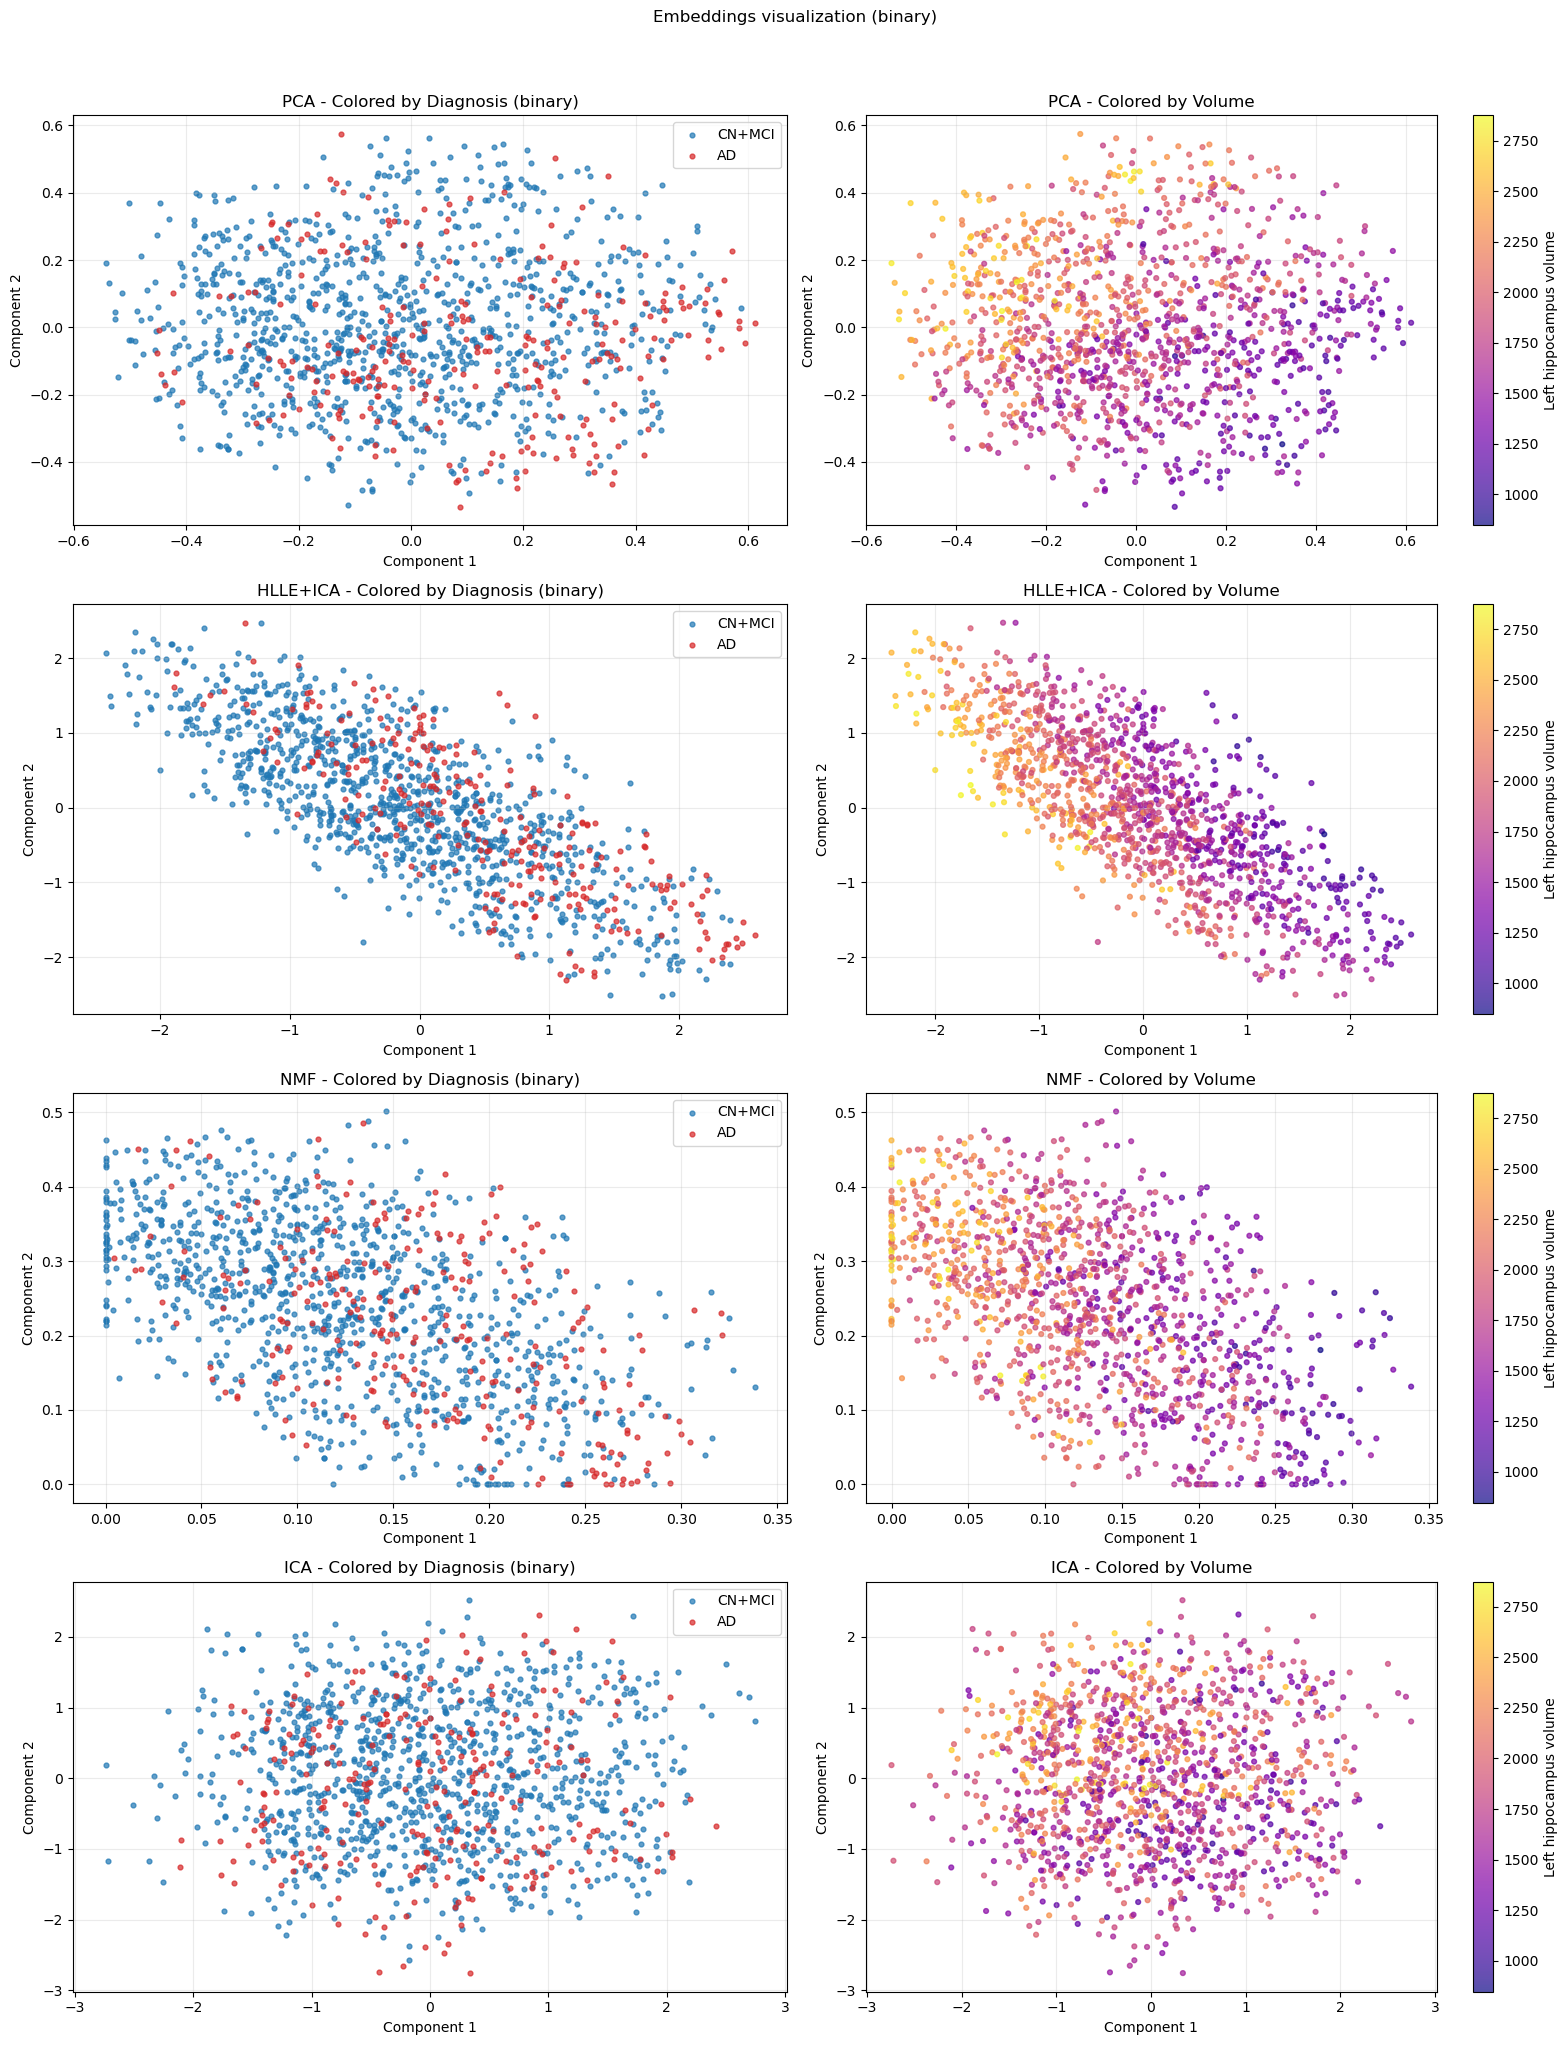

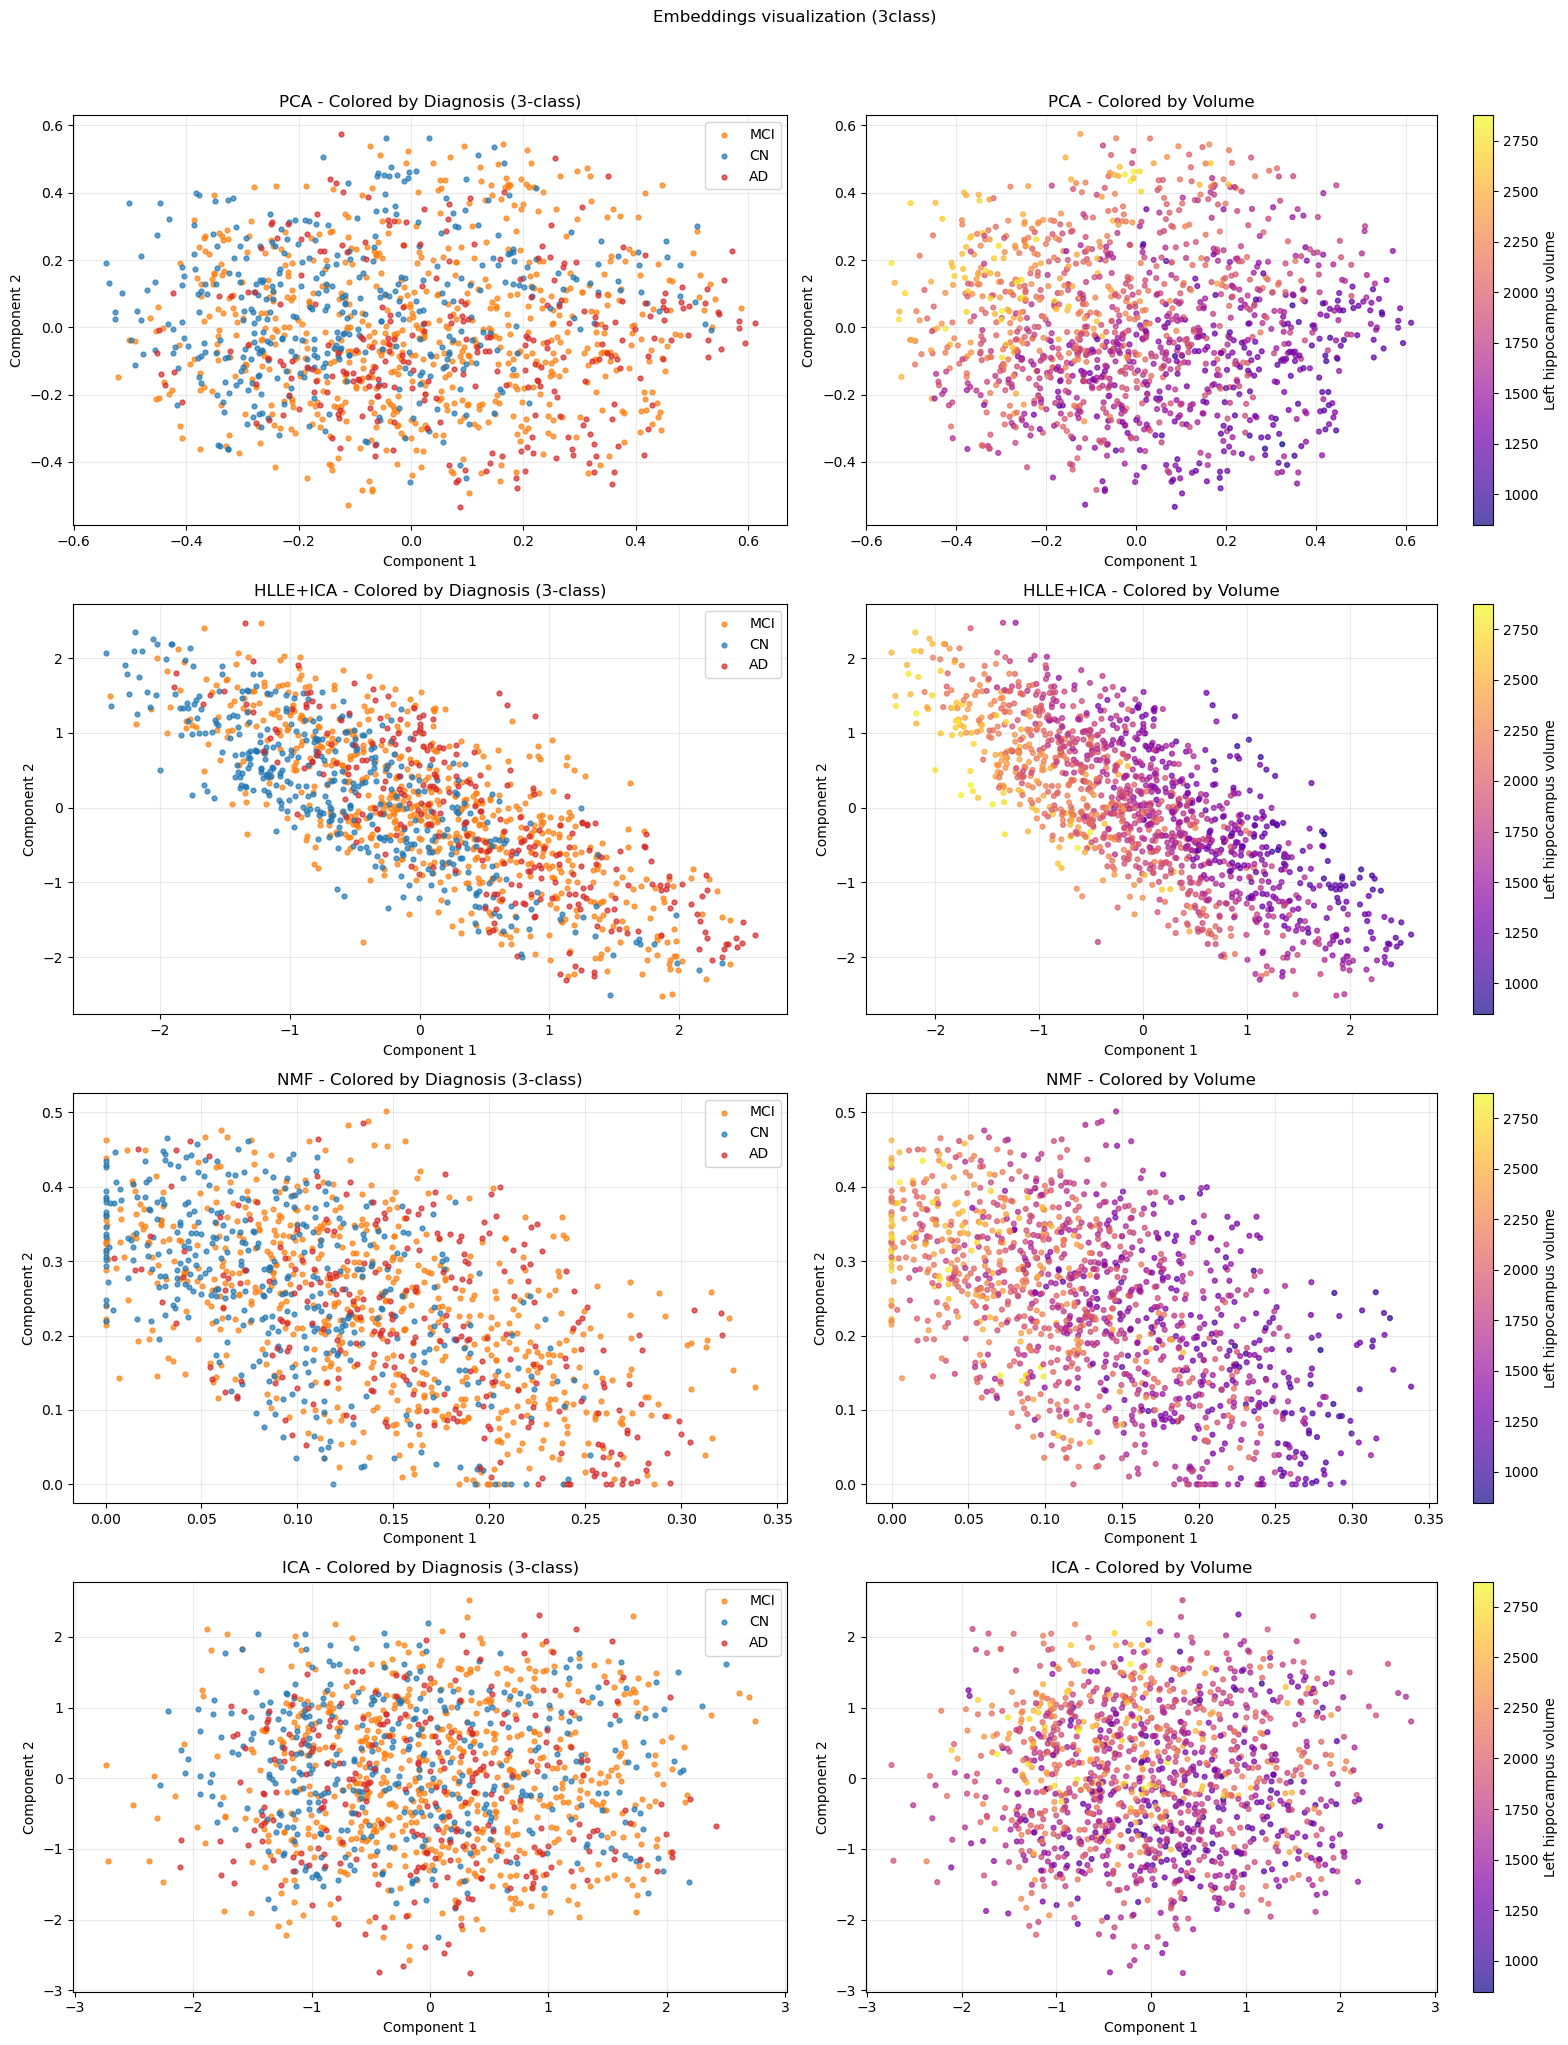

In [ ]:
# 4. Visualize results (two views): binary CN+MCI vs AD, and 3-class MCI/CN/AD
import numpy as np
import matplotlib.pyplot as plt

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'diag_bin' not in globals() or 'diag_raw_valid' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

techniques = ['PCA', 'HLLE+ICA', 'NMF', 'ICA']

def _scatter_diag(ax, x, y, mode):
    if mode == 'binary':
        mask = np.isfinite(diag_bin)
        for cls in [0, 1]:
            m = mask & (diag_bin == cls)
            if np.any(m):
                ax.scatter(x[m], y[m], s=12, alpha=0.7, color=diag_bin_colors[cls], label=diag_bin_name[cls])
        ax.set_title('Colored by Diagnosis (binary)')
        ax.legend(loc='best')
    else:
        mask = np.isfinite(diag_raw_valid)
        for cls in [-1, 0, 1]:
            m = mask & (diag_raw_valid == cls)
            if np.any(m):
                ax.scatter(x[m], y[m], s=12, alpha=0.7, color=diag3_colors[cls], label=diag3_name[cls])
        ax.set_title('Colored by Diagnosis (3-class)')
        ax.legend(loc='best')

for mode in ['binary', '3class']:
    fig, axes = plt.subplots(len(techniques), 2, figsize=(16, 20))
    for i, technique in enumerate(techniques):
        emb = results.get(technique)
        if emb is None or (isinstance(emb, np.ndarray) and emb.size == 0):
            continue
        if isinstance(emb, np.ndarray) and emb.shape[1] < 2:
            continue

        x = emb[:, 0]
        y = emb[:, 1]

        _scatter_diag(axes[i, 0], x, y, mode)
        axes[i, 0].set_xlabel('Component 1')
        axes[i, 0].set_ylabel('Component 2')
        axes[i, 0].set_title(f'{technique} - ' + axes[i, 0].get_title())
        axes[i, 0].grid(True, alpha=0.25)

        vmask = np.isfinite(volume)
        sc = axes[i, 1].scatter(x[vmask], y[vmask], c=volume[vmask], cmap='plasma', alpha=0.7, s=12)
        axes[i, 1].set_title(f'{technique} - Colored by Volume')
        axes[i, 1].set_xlabel('Component 1')
        axes[i, 1].set_ylabel('Component 2')
        axes[i, 1].grid(True, alpha=0.25)
        plt.colorbar(sc, ax=axes[i, 1], label='Left hippocampus volume')

    fig.suptitle(f'Embeddings visualization ({mode})', y=1.02)
    plt.tight_layout()
    plt.show()


In [17]:
# 5. Correlation Analysis (binary + 3-class diagnosis)
import numpy as np

if 'results' not in globals():
    raise RuntimeError('results not found. Run embedding cells first.')
if 'diag_bin' not in globals() or 'diag3_idx' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

techniques = ['PCA', 'HLLE+ICA', 'NMF', 'ICA']

print('\nCorrelation Analysis:')
for technique in techniques:
    emb = results.get(technique)
    if emb is None or (isinstance(emb, np.ndarray) and emb.size == 0):
        continue
    if not isinstance(emb, np.ndarray):
        emb = np.asarray(emb)

    print(f'\n{technique} Analysis:')
    num_components = emb.shape[1]

    # Diagnosis (binary)
    if np.any(np.isfinite(diag_bin)):
        mask = np.isfinite(diag_bin)
        for comp_idx in range(num_components):
            corr = np.corrcoef(emb[mask, comp_idx], diag_bin[mask])[0, 1]
            print(f'  Component {comp_idx + 1} corr(diagnosis binary CN+MCI vs AD): {corr:.4f}')

    # Diagnosis (3-class as ordinal index) + per-class means
    if np.any(np.isfinite(diag3_idx)):
        mask = np.isfinite(diag3_idx)
        for comp_idx in range(num_components):
            corr = np.corrcoef(emb[mask, comp_idx], diag3_idx[mask])[0, 1]
            print(f'  Component {comp_idx + 1} corr(diagnosis 3-class idx): {corr:.4f}')
            # class means (more interpretable than ordinal corr)
            for cls in [-1, 0, 1]:
                m = np.isfinite(diag_raw_valid) & (diag_raw_valid == cls)
                if np.any(m):
                    mu = float(np.mean(emb[m, comp_idx]))
                    sd = float(np.std(emb[m, comp_idx]))
                    print(f'    mean±std {diag3_name[cls]}: {mu:.4f}±{sd:.4f}')

    # Age
    if np.any(np.isfinite(age)):
        mask = np.isfinite(age)
        for comp_idx in range(num_components):
            corr = np.corrcoef(emb[mask, comp_idx], age[mask])[0, 1]
            print(f'  Component {comp_idx + 1} corr(age): {corr:.4f}')

    # Sex
    if np.any(np.isfinite(sex)):
        mask = np.isfinite(sex)
        for comp_idx in range(num_components):
            corr = np.corrcoef(emb[mask, comp_idx], sex[mask])[0, 1]
            print(f'  Component {comp_idx + 1} corr(sex): {corr:.4f}')

    # Volume
    if np.any(np.isfinite(volume)):
        mask = np.isfinite(volume)
        for comp_idx in range(num_components):
            corr = np.corrcoef(emb[mask, comp_idx], volume[mask])[0, 1]
            print(f'  Component {comp_idx + 1} corr(volume): {corr:.4f}')



Correlation Analysis:

PCA Analysis:
  Component 1 corr(diagnosis binary CN+MCI vs AD): 0.2056
  Component 2 corr(diagnosis binary CN+MCI vs AD): -0.1155
  Component 3 corr(diagnosis binary CN+MCI vs AD): 0.2006
  Component 4 corr(diagnosis binary CN+MCI vs AD): 0.1680
  Component 1 corr(diagnosis 3-class idx): 0.0555
    mean±std MCI: 0.0194±0.2369
    mean±std CN: -0.1009±0.2270
    mean±std AD: 0.1004±0.2461
  Component 2 corr(diagnosis 3-class idx): -0.0272
    mean±std MCI: -0.0111±0.2237
    mean±std CN: 0.0528±0.2030
    mean±std AD: -0.0503±0.2187
  Component 3 corr(diagnosis 3-class idx): 0.0344
    mean±std MCI: 0.0224±0.2080
    mean±std CN: -0.0934±0.1712
    mean±std AD: 0.0823±0.2041
  Component 4 corr(diagnosis 3-class idx): 0.1040
    mean±std MCI: -0.0051±0.1749
    mean±std CN: -0.0325±0.1852
    mean±std AD: 0.0601±0.1737
  Component 1 corr(age): 0.1888
  Component 2 corr(age): -0.0585
  Component 3 corr(age): 0.1655
  Component 4 corr(age): -0.0381
  Component 1 co

In [ ]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-0.716, Skew=0.170, Negent=0.056
component_1: Kurt=-0.423, Skew=0.189, Negent=0.045
component_2: Kurt=-0.297, Skew=0.188, Negent=0.040
component_3: Kurt=-0.268, Skew=-0.117, Negent=0.031

HLLE+ICA Quality Metrics:
component_0: Kurt=-0.453, Skew=0.150, Negent=0.407
component_1: Kurt=-0.581, Skew=-0.093, Negent=0.413
component_2: Kurt=-0.464, Skew=-0.127, Negent=0.417
component_3: Kurt=0.052, Skew=0.449, Negent=0.392

NMF Quality Metrics:
component_0: Kurt=-0.622, Skew=0.221, Negent=0.005
component_1: Kurt=-0.738, Skew=-0.151, Negent=0.011
component_2: Kurt=-0.697, Skew=0.093, Negent=0.017
component_3: Kurt=-0.610, Skew=0.089, Negent=0.009

ICA Quality Metrics:
component_0: Kurt=-0.572, Skew=0.135, Negent=0.417
component_1: Kurt=-0.674, Skew=-0.053, Negent=0.426
component_2: Kurt=-0.613, Skew=-0.149, Negent=0.425
component_3: Kurt=-0.585, Skew=-0.069, Negent=0.421


Projecting individual latent vectors onto learned components...
Projection shapes:
PCA: (696, 4)
ICA: (696, 4)
HLLE+ICA: (696, 2)


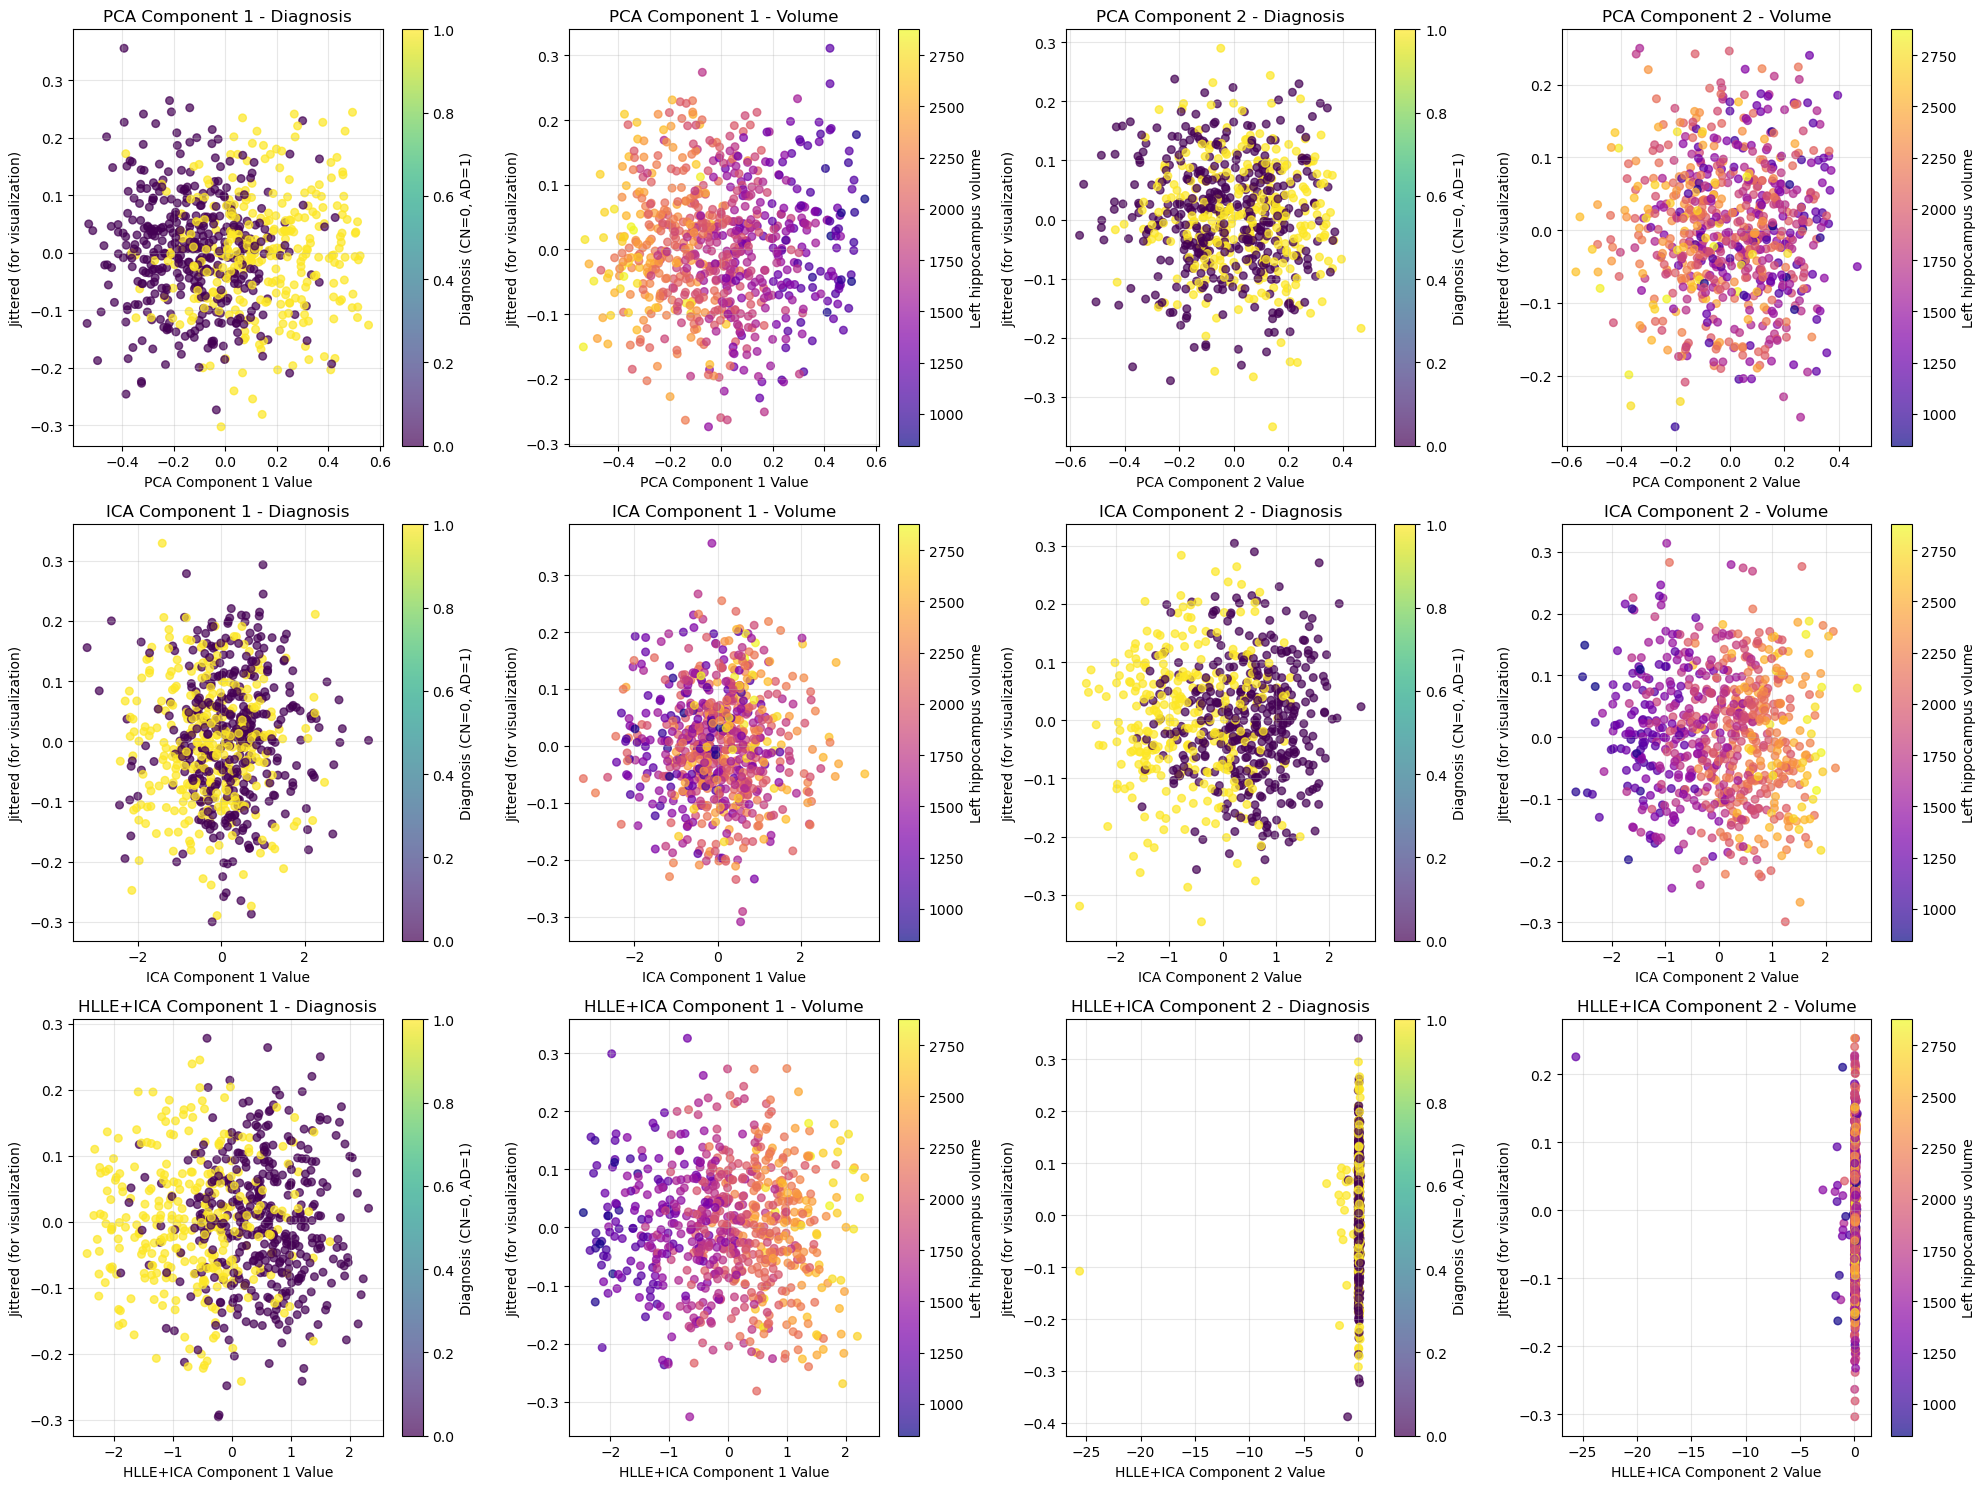

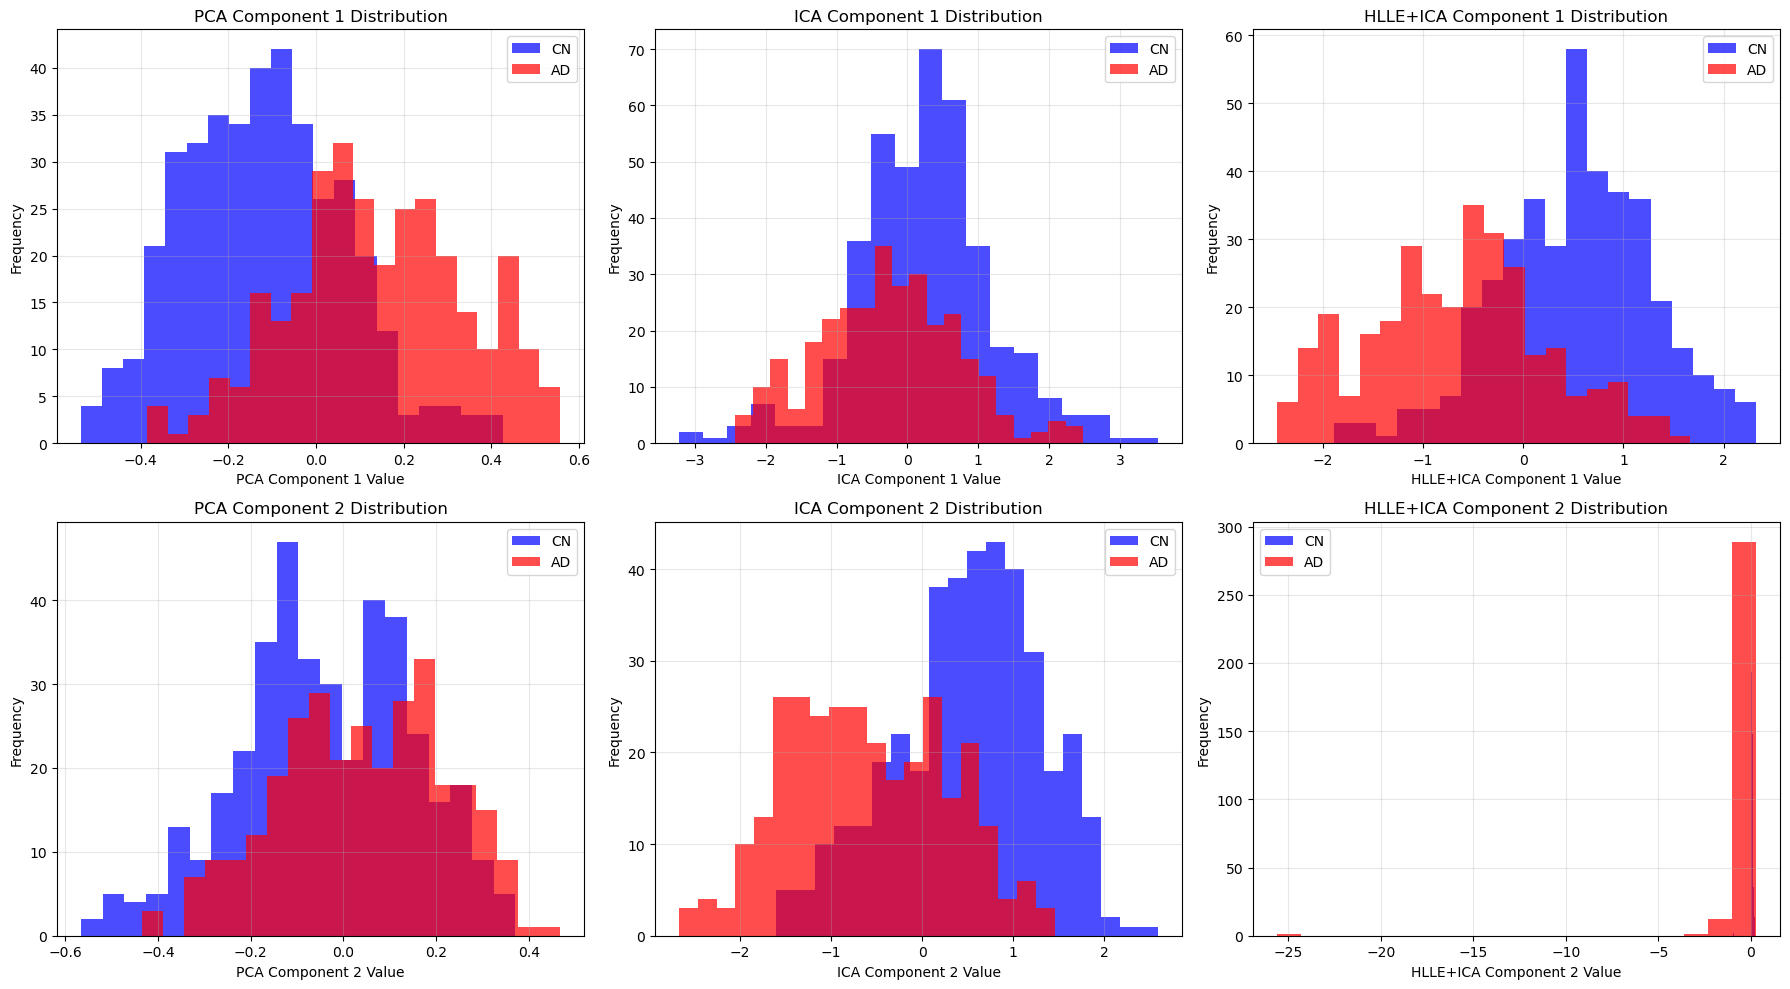

In [ ]:
# 9. Project latent vectors onto learned components + visualize (binary + 3-class)
import numpy as np
import matplotlib.pyplot as plt

if 'latent_vectors' not in globals():
    raise RuntimeError('latent_vectors not found. Run latent loading cell first.')
if 'pca' not in globals() or 'ica' not in globals():
    raise RuntimeError('pca/ica not found. Run PCA and ICA cells first.')
if 'best_Y_hlle_ica' not in globals():
    print('Note: best_Y_hlle_ica not found yet; HLLE+ICA projections may be skipped.')

X_full = latent_vectors.cpu().numpy()
individual_projections = {}

# PCA and ICA projections
pca_components = pca.components_
individual_projections['PCA'] = X_full @ pca_components.T
ica_components = ica.components_
individual_projections['ICA'] = X_full @ ica_components.T

# HLLE+ICA projection (re-fit HLLE on X used earlier)
if 'best_params' in globals() and best_Y_hlle_ica is not None:
    best_n_neighbors = best_params[0]
    hlle_for_projection = LocallyLinearEmbedding(
        n_neighbors=best_n_neighbors,
        n_components=2,
        method='hessian',
        eigen_solver='dense'
    )
    hlle_for_projection.fit(X)
    Z_full = hlle_for_projection.transform(X_full)
    # ICA after HLLE
    ica_after_hlle = FastICA(n_components=2, random_state=42)
    Z_train = hlle_for_projection.transform(X)
    ica_after_hlle.fit(Z_train)
    individual_projections['HLLE+ICA'] = ica_after_hlle.transform(Z_full)
else:
    individual_projections['HLLE+ICA'] = None

def _scatter_diag(ax, x, y, mode):
    if mode == 'binary':
        mask = np.isfinite(diag_bin)
        for cls in [0, 1]:
            m = mask & (diag_bin == cls)
            if np.any(m):
                ax.scatter(x[m], y[m], s=12, alpha=0.7, color=diag_bin_colors[cls], label=diag_bin_name[cls])
        ax.set_title('Diagnosis (binary)')
        ax.legend(loc='best')
    else:
        mask = np.isfinite(diag_raw_valid)
        for cls in [-1, 0, 1]:
            m = mask & (diag_raw_valid == cls)
            if np.any(m):
                ax.scatter(x[m], y[m], s=12, alpha=0.7, color=diag3_colors[cls], label=diag3_name[cls])
        ax.set_title('Diagnosis (3-class)')
        ax.legend(loc='best')

methods = ['PCA', 'ICA', 'HLLE+ICA']
for method in methods:
    proj = individual_projections.get(method)
    if proj is None:
        print(f'{method}: skipped (projection missing)')
        continue
    if proj.shape[1] < 2:
        print(f'{method}: only {proj.shape[1]} component(s); need >=2 for 2D scatter')
        continue

    x = proj[:, 0]
    y = proj[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    _scatter_diag(axes[0], x, y, 'binary')
    axes[0].set_xlabel('Component 1')
    axes[0].set_ylabel('Component 2')
    axes[0].grid(True, alpha=0.25)

    _scatter_diag(axes[1], x, y, '3class')
    axes[1].set_xlabel('Component 1')
    axes[1].set_ylabel('Component 2')
    axes[1].grid(True, alpha=0.25)

    vmask = np.isfinite(volume)
    sc = axes[2].scatter(x[vmask], y[vmask], c=volume[vmask], cmap='plasma', alpha=0.7, s=12)
    axes[2].set_title('Volume')
    axes[2].set_xlabel('Component 1')
    axes[2].set_ylabel('Component 2')
    axes[2].grid(True, alpha=0.25)
    plt.colorbar(sc, ax=axes[2], label='Left hippocampus volume')

    fig.suptitle(f'{method} projections (component 1 vs 2)')
    plt.tight_layout()
    plt.show()


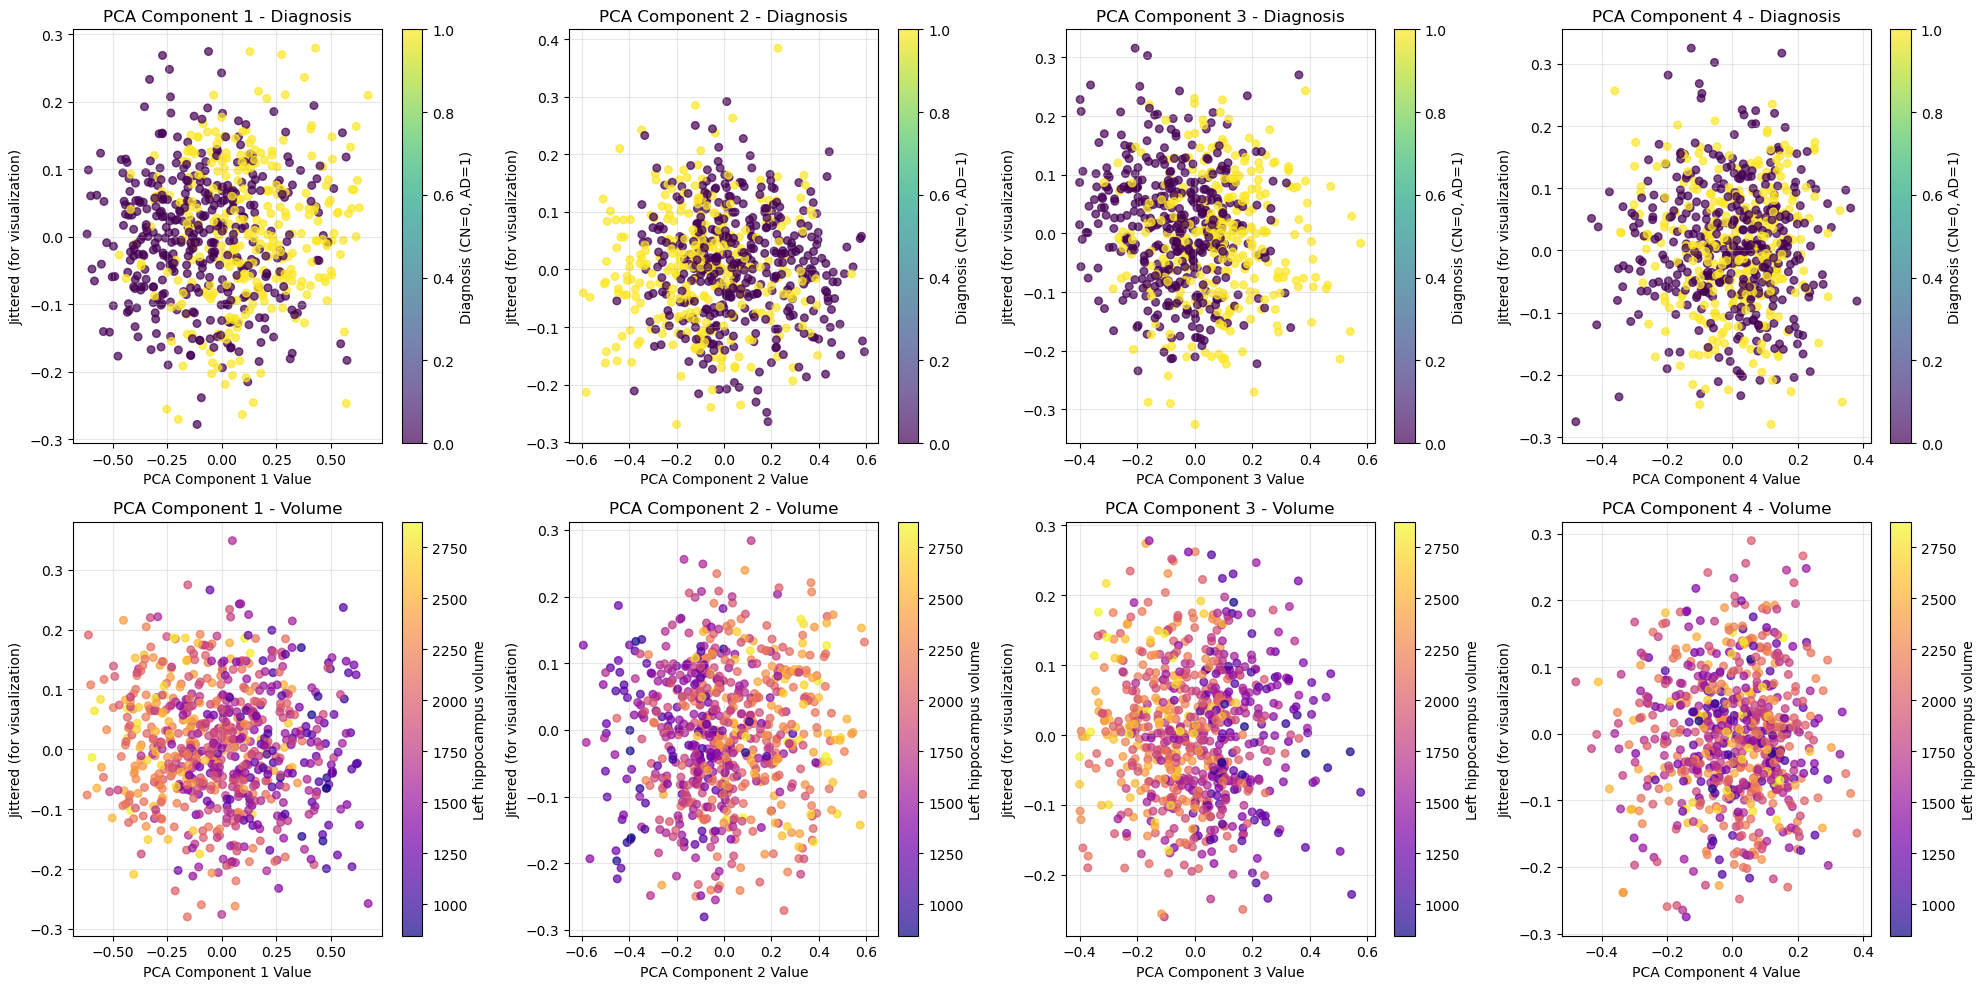

In [86]:
# Plot PCA components vs diagnosis (binary + 3-class) and vs volume
import numpy as np
import matplotlib.pyplot as plt

if 'results' not in globals() or 'PCA' not in results:
    raise RuntimeError('PCA results not found. Run the PCA cell first.')
pca_results = results['PCA']

def _plot_pca_diag(mode):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for i in range(4):
        yjit = np.random.normal(0, 0.08, len(pca_results))
        if mode == 'binary':
            mask = np.isfinite(diag_bin)
            for cls in [0, 1]:
                m = mask & (diag_bin == cls)
                if np.any(m):
                    axes[i].scatter(pca_results[m, i], yjit[m], s=12, alpha=0.7, color=diag_bin_colors[cls], label=diag_bin_name[cls])
            axes[i].set_title(f'PCA {i+1} - Diagnosis (binary)')
        else:
            mask = np.isfinite(diag_raw_valid)
            for cls in [-1, 0, 1]:
                m = mask & (diag_raw_valid == cls)
                if np.any(m):
                    axes[i].scatter(pca_results[m, i], yjit[m], s=12, alpha=0.7, color=diag3_colors[cls], label=diag3_name[cls])
            axes[i].set_title(f'PCA {i+1} - Diagnosis (3-class)')
        axes[i].set_xlabel(f'PCA Component {i+1} value')
        axes[i].set_yticks([])
        axes[i].grid(True, alpha=0.25)
        axes[i].legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

_plot_pca_diag('binary')
_plot_pca_diag('3class')

# Volume plots (unchanged label-wise)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
vmask = np.isfinite(volume)
for i in range(4):
    yjit = np.random.normal(0, 0.08, int(np.sum(vmask)))
    sc = axes[i].scatter(pca_results[vmask, i], yjit, c=volume[vmask], cmap='plasma', alpha=0.7, s=12)
    axes[i].set_title(f'PCA {i+1} - Volume')
    axes[i].set_xlabel(f'PCA Component {i+1} value')
    axes[i].set_yticks([])
    axes[i].grid(True, alpha=0.25)
    plt.colorbar(sc, ax=axes[i], label='Left hippocampus volume')
plt.tight_layout()
plt.show()



Analyzing volume encoding across all latent dimensions:
Latent dim 1: volume correlation = -0.0290
Latent dim 2: volume correlation = 0.1452
Latent dim 3: volume correlation = 0.0502
Latent dim 4: volume correlation = -0.0335
Latent dim 5: volume correlation = -0.2026
Latent dim 6: volume correlation = -0.0421
Latent dim 7: volume correlation = 0.4520
Latent dim 8: volume correlation = -0.0314
Latent dim 9: volume correlation = 0.0173
Latent dim 10: volume correlation = -0.0177
Latent dim 11: volume correlation = -0.0025
Latent dim 12: volume correlation = -0.1195
Latent dim 13: volume correlation = 0.0778
Latent dim 14: volume correlation = 0.0057
Latent dim 15: volume correlation = -0.0387
Latent dim 16: volume correlation = -0.0632
Latent dim 17: volume correlation = -0.0535
Latent dim 18: volume correlation = 0.0066
Latent dim 19: volume correlation = 0.0084
Latent dim 20: volume correlation = -0.0494
Latent dim 21: volume correlation = -0.0311
Latent dim 22: volume correlation = 

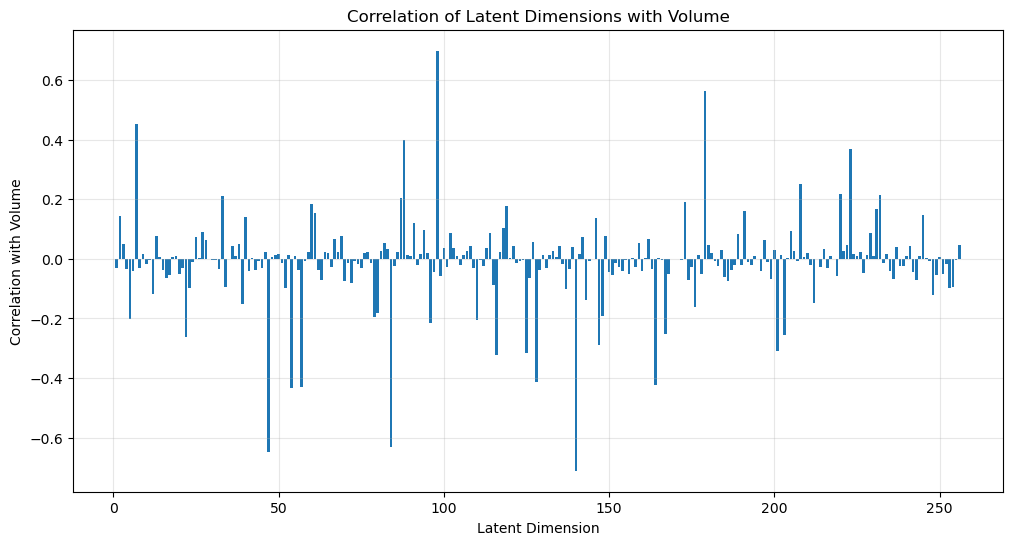

In [11]:
# Test if volume information is distributed across all dimensions
print('\nAnalyzing volume encoding across all latent dimensions:')

latent_volume_correlations = []
mask = np.isfinite(volume)
for dim in range(X.shape[1]):
    if np.any(mask):
        corr = np.corrcoef(X[mask, dim], volume[mask])[0, 1]
    else:
        corr = float('nan')
    latent_volume_correlations.append(corr)
    print(f'Latent dim {dim+1}: volume correlation = {corr:.4f}')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

if np.any(mask):
    lr = LinearRegression()
    lr.fit(X[mask], volume[mask])
    predicted_volumes = lr.predict(X[mask])
    r2 = r2_score(volume[mask], predicted_volumes)
    quality = 'well' if r2 > 0.7 else 'poorly'
    print(f'\nLinear regression R² for predicting volume: {r2:.4f}')
    print(f'This suggests volume information is {quality} encoded in the full latent space')
else:
    print('No finite volume values for linear regression.')

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(latent_volume_correlations) + 1), latent_volume_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Volume')
plt.title('Correlation of Latent Dimensions with Volume')
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.019, Calinski-Harabasz=26.3, Davies-Bouldin=7.004
K=3: Silhouette=0.016, Calinski-Harabasz=21.6, Davies-Bouldin=6.595
K=4: Silhouette=0.013, Calinski-Harabasz=19.7, Davies-Bouldin=6.081


K=5: Silhouette=0.013, Calinski-Harabasz=17.6, Davies-Bouldin=6.066
K=6: Silhouette=0.013, Calinski-Harabasz=16.0, Davies-Bouldin=5.827
K=7: Silhouette=0.011, Calinski-Harabasz=14.6, Davies-Bouldin=5.668
K=8: Silhouette=0.008, Calinski-Harabasz=13.7, Davies-Bouldin=5.728
K=9: Silhouette=0.008, Calinski-Harabasz=13.0, Davies-Bouldin=5.474
K=10: Silhouette=0.008, Calinski-Harabasz=12.1, Davies-Bouldin=5.275

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 10


In [13]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.019, AIC=911121.8, BIC=1254079.4
K=3: Silhouette=0.013, AIC=913828.3, BIC=1428267.3
K=4: Silhouette=0.012, AIC=892881.0, BIC=1578801.4
K=5: Silhouette=0.007, AIC=729325.8, BIC=1586727.6
K=6: Silhouette=0.007, AIC=354713.5, BIC=1383596.7
K=7: Silhouette=0.007, AIC=-66837.4, BIC=1133527.2
K=8: Silhouette=0.012, AIC=-257595.0, BIC=1114250.9
K=9: Silhouette=0.010, AIC=-470431.0, BIC=1072896.3
K=10: Silhouette=0.006, AIC=-669333.9, BIC=1045474.8

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 1303 noise points (invalid)
eps=0.5: 0 clusters, 1303 noise points (invalid)
eps=0.7: 0 clusters, 1303 noise points (invalid)
eps=1.0: 0 clusters, 1303 noise points (invalid)
eps=1.5: 0 clusters, 1303 noise points (invalid)
eps=2.0: 0 clusters, 1303 noise points (invalid)


In [11]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [2, 3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [2, 3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=2: Silhouette=0.024
Linkage=ward, K=3: Silhouette=0.019
Linkage=ward, K=4: Silhouette=0.017
Linkage=ward, K=5: Silhouette=0.014
Linkage=complete, K=2: Silhouette=0.033
Linkage=complete, K=3: Silhouette=0.015
Linkage=complete, K=4: Silhouette=0.010
Linkage=complete, K=5: Silhouette=0.010
Linkage=average, K=2: Silhouette=0.087
Linkage=average, K=3: Silhouette=0.059
Linkage=average, K=4: Silhouette=0.044
Linkage=average, K=5: Silhouette=0.039

5. Spectral Clustering:


KeyboardInterrupt: 


6. Visualization of Clustering Results:
UMAP failed (check_array() got an unexpected keyword argument 'ensure_all_finite'); using t-SNE for visualization


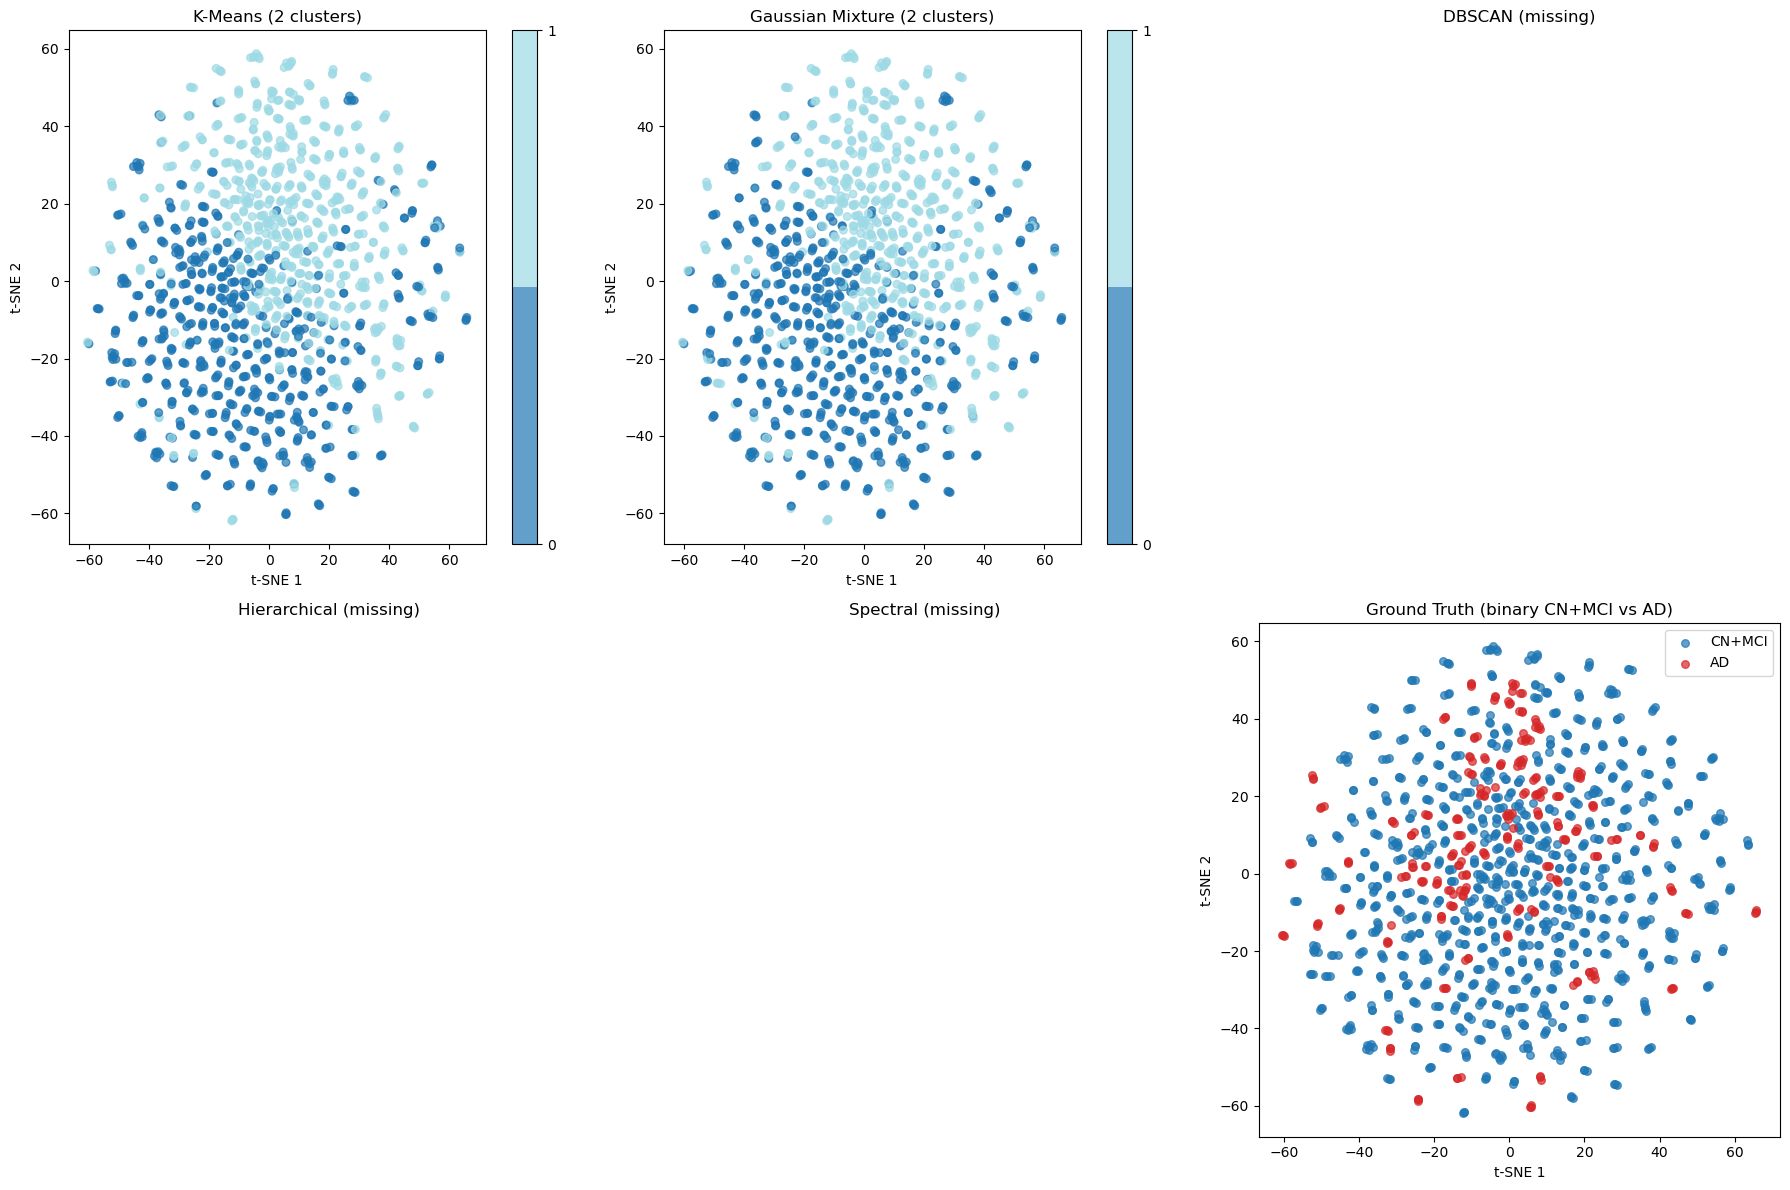

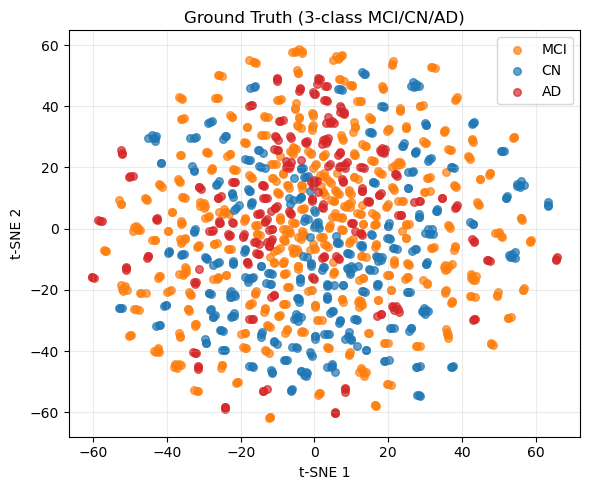

In [14]:
# 6. Visualize clustering results + ground truth (binary + 3-class)
print('\n6. Visualization of Clustering Results:')

import numpy as np
import matplotlib.pyplot as plt

embedding_label = 'UMAP'
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_vis = reducer.fit_transform(X_scaled)
    print('Using UMAP for visualization')
except Exception as e:
    from sklearn.manifold import TSNE
    embedding_label = 't-SNE'
    print(f'UMAP failed ({e}); using t-SNE for visualization')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_vis = tsne.fit_transform(X_scaled)

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

def _scatter_clusters(ax, labels, title):
    labels = np.asarray(labels)
    uniq = sorted(set(labels.tolist()))
    idx_map = {lab: i for i, lab in enumerate(uniq)}
    color_ids = np.vectorize(idx_map.get)(labels)
    cmap = plt.get_cmap('tab20', len(uniq))
    sc = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=color_ids, cmap=cmap, s=30, alpha=0.7, vmin=0, vmax=len(uniq)-1)
    ax.set_title(f'{title} ({len(uniq)} clusters)')
    ax.set_xlabel(f'{embedding_label} 1')
    ax.set_ylabel(f'{embedding_label} 2')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(uniq)))
    cbar.ax.set_yticklabels(uniq)

for i, (method, name) in enumerate(zip(methods, method_names)):
    ax = axes[i]
    if method not in clustering_results:
        ax.axis('off')
        ax.set_title(f'{name} (missing)')
        continue
    _scatter_clusters(ax, clustering_results[method], name)

# Ground truth (binary) in the last panel
ax = axes[5]
mask = np.isfinite(diag_bin)
for cls in [0, 1]:
    m = mask & (diag_bin == cls)
    if np.any(m):
        ax.scatter(X_vis[m, 0], X_vis[m, 1], s=30, alpha=0.7, color=diag_bin_colors[cls], label=diag_bin_name[cls])
ax.set_title('Ground Truth (binary CN+MCI vs AD)')
ax.set_xlabel(f'{embedding_label} 1')
ax.set_ylabel(f'{embedding_label} 2')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

# Separate figure: ground truth (3-class)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
mask = np.isfinite(diag_raw_valid)
for cls in [-1, 0, 1]:
    m = mask & (diag_raw_valid == cls)
    if np.any(m):
        ax.scatter(X_vis[m, 0], X_vis[m, 1], s=30, alpha=0.7, color=diag3_colors[cls], label=diag3_name[cls])
ax.set_title('Ground Truth (3-class MCI/CN/AD)')
ax.set_xlabel(f'{embedding_label} 1')
ax.set_ylabel(f'{embedding_label} 2')
ax.legend(loc='best')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [15]:
# 7. Analyze cluster characteristics (binary + 3-class diagnosis)
import numpy as np
from collections import Counter

print('\n7. Cluster Analysis:')

if 'KMeans_Best' not in clustering_results:
    raise RuntimeError('KMeans_Best not found in clustering_results')

best_labels = np.asarray(clustering_results['KMeans_Best'])
unique_clusters = sorted(set(best_labels.tolist()))
print(f'Analyzing K-Means with {len(unique_clusters)} clusters')

for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id
    n = int(np.sum(cluster_mask))
    if n == 0:
        continue

    # Binary view (CN+MCI vs AD)
    bin_mask = cluster_mask & np.isfinite(diag_bin)
    ad_ratio = float(np.mean(diag_bin[bin_mask] == 1)) if np.any(bin_mask) else float('nan')

    # 3-class breakdown
    cls_mask = cluster_mask & np.isfinite(diag_raw_valid)
    cls_vals = diag_raw_valid[cls_mask].astype(int) if np.any(cls_mask) else np.array([], dtype=int)
    cls_counts = Counter(cls_vals.tolist())

    # Volume
    vmask = cluster_mask & np.isfinite(volume)
    vmean = float(np.mean(volume[vmask])) if np.any(vmask) else float('nan')
    vstd = float(np.std(volume[vmask])) if np.any(vmask) else float('nan')

    print(f'\nCluster {cluster_id}:')
    print(f'  Size: {n}')
    print(f'  AD ratio (binary): {ad_ratio:.3f}')
    print('  3-class counts:', {diag3_name.get(k, str(k)): int(v) for k, v in cls_counts.items()})
    print(f'  Volume mean±std: {vmean:.4f}±{vstd:.4f}')

# 8. Save cluster labels
print('\n8. Saving cluster labels:')
np.save('unsupervised_cluster_labels.npy', best_labels)
print('Saved cluster labels to unsupervised_cluster_labels.npy')
print(f'Shape: {best_labels.shape}  Unique clusters: {unique_clusters}')



7. Cluster Analysis:
Analyzing K-Means with 2 clusters

Cluster 0:
  Size: 638
  AD ratio (binary): 0.161
  3-class counts: {'AD': 103, 'MCI': 293, 'CN': 242}
  Volume mean±std: 1971.9268±384.5590

Cluster 1:
  Size: 665
  AD ratio (binary): 0.244
  3-class counts: {'MCI': 356, 'AD': 162, 'CN': 147}
  Volume mean±std: 1687.8903±355.8668

8. Saving cluster labels:
Saved cluster labels to unsupervised_cluster_labels.npy
Shape: (1303,)  Unique clusters: [0, 1]


In [17]:
# 9. Map cluster IDs to diagnosis labels (binary + 3-class)
print('\n9. Cluster-to-Diagnosis Mapping:')
from collections import Counter
import numpy as np

def _purity_from_counts(counts):
    if not counts:
        return float('nan'), None
    major_label, major_count = max(counts.items(), key=lambda kv: kv[1])
    total = sum(counts.values())
    return major_count / total if total else float('nan'), major_label

def summarize_cluster_labels(labels, targets, class_values, class_name_map, title):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    unique_clusters = sorted(set(labels.tolist()))
    print(f'\n{title}')
    total_major = 0
    total_n = 0
    for cluster_id in unique_clusters:
        cmask = labels == cluster_id
        tmask = cmask & np.isfinite(targets)
        t = targets[tmask].astype(int)
        # restrict to known class values
        t = t[np.isin(t, class_values)]
        counts = Counter(t.tolist())
        n = sum(counts.values())
        purity, major = _purity_from_counts(counts)
        if n:
            total_major += counts.get(major, 0)
            total_n += n
        pretty = {class_name_map.get(k, str(k)): int(v) for k, v in counts.items()}
        major_name = class_name_map.get(major, str(major)) if major is not None else 'N/A'
        print(f'  Cluster {cluster_id}: n={n} counts={pretty} majority={major_name} purity={purity:.3f}')

    if total_n:
        print(f'  Overall purity: {total_major/total_n:.3f} (coverage={total_n})')

for method_name, labels in clustering_results.items():
    print(f'\nMethod: {method_name}')
    summarize_cluster_labels(
        labels,
        diag_bin,
        class_values=[0, 1],
        class_name_map=diag_bin_name,
        title='  Binary (CN+MCI vs AD)'
    )
    summarize_cluster_labels(
        labels,
        diag_raw_valid,
        class_values=[-1, 0, 1],
        class_name_map=diag3_name,
        title='  3-class (MCI/CN/AD)'
    )



9. Cluster-to-Diagnosis Mapping:

Method: KMeans_3

  Binary (CN+MCI vs AD)
  Cluster 0: n=536 counts={'CN+MCI': 432, 'AD': 104} majority=CN+MCI purity=0.806
  Cluster 1: n=270 counts={'CN+MCI': 199, 'AD': 71} majority=CN+MCI purity=0.737
  Cluster 2: n=497 counts={'AD': 90, 'CN+MCI': 407} majority=CN+MCI purity=0.819
  Overall purity: 0.797 (coverage=1303)

  3-class (MCI/CN/AD)
  Cluster 0: n=536 counts={'MCI': 277, 'AD': 104, 'CN': 155} majority=MCI purity=0.517
  Cluster 1: n=270 counts={'MCI': 143, 'AD': 71, 'CN': 56} majority=MCI purity=0.530
  Cluster 2: n=497 counts={'AD': 90, 'MCI': 229, 'CN': 178} majority=MCI purity=0.461
  Overall purity: 0.498 (coverage=1303)

Method: KMeans_Best

  Binary (CN+MCI vs AD)
  Cluster 0: n=638 counts={'AD': 103, 'CN+MCI': 535} majority=CN+MCI purity=0.839
  Cluster 1: n=665 counts={'CN+MCI': 503, 'AD': 162} majority=CN+MCI purity=0.756
  Overall purity: 0.797 (coverage=1303)

  3-class (MCI/CN/AD)
  Cluster 0: n=638 counts={'AD': 103, 'MCI': 


10. Creating pseudo labels from GMM_Best clusters...
Cluster 0: AD ratio = 0.790
Cluster 1: AD ratio = 0.150
Assigning AD to cluster 0, CN to cluster 1
Saved pseudo labels to /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo CN volume mean±std: 2177.6926±273.6919
Pseudo AD volume mean±std: 1477.6985±248.3089


/tmp/ipykernel_2776170/3621281693.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


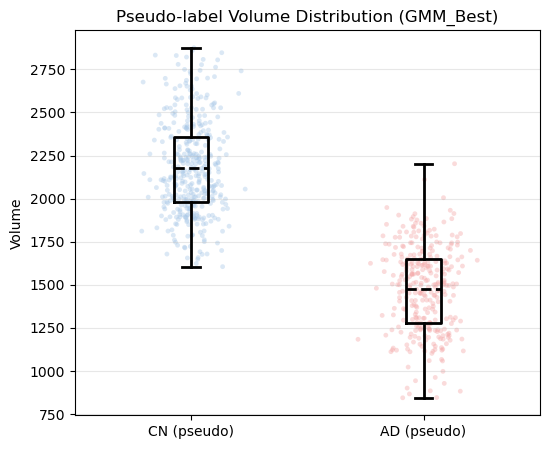

In [42]:
# 10. Create pseudo labels from GMM_Best clusters and analyze volume (binary CN+MCI vs AD)
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter

print('\n10. Creating pseudo labels from GMM_Best clusters...')

if 'GMM_Best' not in clustering_results:
    print('GMM_Best not found in clustering_results.')
else:
    gmm_labels = np.asarray(clustering_results['GMM_Best'])
    if 'valid_filenames' in globals() and len(gmm_labels) != len(valid_filenames):
        print(f'Warning: label count mismatch: {len(gmm_labels)} vs {len(valid_filenames)}')

    # Binary mapping: choose the cluster with highest AD ratio as AD
    diag_mask_bin = np.isfinite(diag_bin)
    cluster_ids = sorted(set(gmm_labels.tolist()))
    cluster_ad_ratio = {}
    print('Cluster diagnosis summaries:')
    for cid in cluster_ids:
        m_bin = (gmm_labels == cid) & diag_mask_bin
        if np.any(m_bin):
            cluster_ad_ratio[cid] = float(np.mean(diag_bin[m_bin] == 1))
        else:
            cluster_ad_ratio[cid] = float('nan')

        # 3-class breakdown (for inspection only)
        m3 = (gmm_labels == cid) & np.isfinite(diag_raw_valid)
        vals = diag_raw_valid[m3].astype(int) if np.any(m3) else np.array([], dtype=int)
        counts = Counter(vals.tolist())
        pretty = {diag3_name.get(k, str(k)): int(v) for k, v in counts.items()}
        print(f'  Cluster {cid}: AD_ratio(bin)={cluster_ad_ratio[cid]:.3f}  3-class={pretty}')

    valid_ratios = {cid: r for cid, r in cluster_ad_ratio.items() if np.isfinite(r)}
    if not valid_ratios:
        print('No valid diagnosis labels to map clusters.')
    else:
        ad_cluster = max(valid_ratios, key=valid_ratios.get)
        nonad_cluster = min(valid_ratios, key=valid_ratios.get)
        print(f'Assigning AD to cluster {ad_cluster}, CN+MCI to cluster {nonad_cluster}')

        pseudo_diag = np.zeros(len(gmm_labels), dtype=int)
        pseudo_diag[gmm_labels == ad_cluster] = 1

        if os.path.exists(labels_path):
            pseudo_labels = {}
            for idx, filename in enumerate(valid_filenames):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                if base_name not in label_map:
                    continue
                label = label_map[base_name]
                label_tensor = label.clone() if isinstance(label, torch.Tensor) else torch.tensor(label, dtype=torch.float32)
                label_tensor = label_tensor.view(-1)

                # [pseudo_bin_diag, real_diag, age, sex, volume, ...]
                pseudo_value = torch.tensor(pseudo_diag[idx], dtype=label_tensor.dtype)
                pseudo_label = torch.cat([pseudo_value.view(1), label_tensor], dim=0)
                pseudo_labels[base_name] = pseudo_label

            pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
            torch.save(pseudo_labels, pseudo_path)
            print(f'Saved pseudo labels to {pseudo_path}')
        else:
            print(f'labels.pt not found at {labels_path}; cannot save pseudo labels.')

        # Volume analysis by pseudo label
        if 'pseudo_labels' in locals():
            pseudo_diag_list = []
            pseudo_volumes = []
            for filename in valid_filenames:
                base_name = os.path.splitext(os.path.basename(filename))[0]
                if base_name in pseudo_labels:
                    lbl = pseudo_labels[base_name]
                    pseudo_diag_list.append(int(lbl[0].item()))
                    pseudo_volumes.append(float(lbl[4].item()) if lbl.numel() > 4 else float('nan'))
                else:
                    pseudo_diag_list.append(-1)
                    pseudo_volumes.append(float('nan'))

            pseudo_diag_arr = np.array(pseudo_diag_list)
            pseudo_vol_arr = np.array(pseudo_volumes, dtype=float)

            vol_mask = np.isfinite(pseudo_vol_arr)
            nonad_mask = (pseudo_diag_arr == 0) & vol_mask
            ad_mask = (pseudo_diag_arr == 1) & vol_mask

            nonad_vol = pseudo_vol_arr[nonad_mask]
            ad_vol = pseudo_vol_arr[ad_mask]

            if nonad_vol.size:
                print(f'Pseudo CN+MCI volume mean±std: {np.mean(nonad_vol):.4f}±{np.std(nonad_vol):.4f}')
            if ad_vol.size:
                print(f'Pseudo AD volume mean±std: {np.mean(ad_vol):.4f}±{np.std(ad_vol):.4f}')

            plt.figure(figsize=(6, 5))
            plt.boxplot([nonad_vol, ad_vol], labels=['CN+MCI (pseudo)', 'AD (pseudo)'], showfliers=True, showmeans=True, meanline=True)
            jitter = 0.08
            if nonad_vol.size:
                plt.scatter(np.random.normal(1, jitter, size=nonad_vol.size), nonad_vol, s=12, alpha=0.4, color='#A7C7E7', edgecolors='none')
            if ad_vol.size:
                plt.scatter(np.random.normal(2, jitter, size=ad_vol.size), ad_vol, s=12, alpha=0.4, color='#F4A6A6', edgecolors='none')
            plt.ylabel('Volume')
            plt.title('Pseudo-label Volume Distribution (GMM_Best)')
            plt.grid(True, axis='y', alpha=0.3)
            plt.show()


In [40]:
# 11. Unsupervised HLLE+ICA component ranking (stability + reconstruction impact)
if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')

if 'best_params' in globals() and best_params is not None:
    n_neighbors = best_params[0]
    n_components = best_params[1]
else:
    n_neighbors = 300
    n_components = 4
    print('best_params not found; using defaults.')

hlle_full = LocallyLinearEmbedding(
    n_neighbors=n_neighbors,
    n_components=n_components,
    method='hessian',
    eigen_solver='dense'
)
Z_full = hlle_full.fit_transform(X)

ica_full = FastICA(n_components=n_components, random_state=42)
Y_full = ica_full.fit_transform(Z_full)

Z_recon_full = ica_full.inverse_transform(Y_full)
mse_full = np.mean((Z_full - Z_recon_full) ** 2)

impact = []
for i in range(n_components):
    Y_mask = Y_full.copy()
    Y_mask[:, i] = 0.0
    Z_recon = ica_full.inverse_transform(Y_mask)
    mse_i = np.mean((Z_full - Z_recon) ** 2)
    impact.append(mse_i - mse_full)
impact = np.asarray(impact)

n_boot = 5
sample_frac = 0.8
rng = np.random.default_rng(42)
stability_scores = np.zeros(n_components)
valid_runs = 0

def _safe_corr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return 0.0
    a = a[mask]
    b = b[mask]
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return abs(np.corrcoef(a, b)[0, 1])

def _greedy_match(corr):
    corr = corr.copy()
    matched = [-1] * n_components
    used_rows = set()
    used_cols = set()
    for _ in range(n_components):
        max_val = -np.inf
        max_r = -1
        max_c = -1
        for r in range(n_components):
            if r in used_rows:
                continue
            for c in range(n_components):
                if c in used_cols:
                    continue
                val = corr[r, c]
                if val > max_val:
                    max_val = val
                    max_r = r
                    max_c = c
        if max_r == -1:
            break
        matched[max_r] = max_c
        used_rows.add(max_r)
        used_cols.add(max_c)
    return matched

for b in range(n_boot):
    idx = rng.choice(X.shape[0], size=int(X.shape[0] * sample_frac), replace=True)
    n_neighbors_b = min(n_neighbors, len(idx) - 1)
    if n_neighbors_b < 2:
        continue
    try:
        hlle_b = LocallyLinearEmbedding(
            n_neighbors=n_neighbors_b,
            n_components=n_components,
            method='hessian',
            eigen_solver='dense'
        )
        Z_b = hlle_b.fit_transform(X[idx])
        ica_b = FastICA(n_components=n_components, random_state=42 + b)
        Y_b = ica_b.fit_transform(Z_b)

        corr = np.zeros((n_components, n_components))
        for i in range(n_components):
            for j in range(n_components):
                corr[i, j] = _safe_corr(Y_full[idx, i], Y_b[:, j])

        matched = _greedy_match(corr)
        for i, j in enumerate(matched):
            if j >= 0:
                stability_scores[i] += corr[i, j]
        valid_runs += 1
    except Exception as e:
        print(f'Bootstrap {b} failed: {e}')

if valid_runs > 0:
    stability_scores /= valid_runs
else:
    stability_scores[:] = np.nan

def _normalize(x):
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return x
    min_x = np.nanmin(x)
    max_x = np.nanmax(x)
    if np.isclose(max_x, min_x):
        return np.zeros_like(x)
    return (x - min_x) / (max_x - min_x)

impact_norm = _normalize(impact)
stability_norm = _normalize(stability_scores)
combined = 0.5 * impact_norm + 0.5 * stability_norm

order = np.argsort(-combined)
print('\nUnsupervised HLLE+ICA component ranking (higher is more significant):')
for rank, i in enumerate(order, 1):
    print(f'{rank}. component_{i}: stability={stability_scores[i]:.3f}, impact={impact[i]:.6f}, score={combined[i]:.3f}')

unsupervised_scores = {
    'stability': stability_scores,
    'impact': impact,
    'combined': combined,
    'order': order,
    'n_neighbors': n_neighbors,
    'n_components': n_components,
    'n_boot': n_boot,
    'sample_frac': sample_frac,
}



Unsupervised HLLE+ICA component ranking (higher is more significant):
1. component_2: stability=0.942, impact=0.000359, score=0.500
2. component_1: stability=0.930, impact=0.000359, score=0.482
3. component_3: stability=0.897, impact=0.000359, score=0.428
4. component_0: stability=0.631, impact=0.000359, score=0.000


In [43]:
# 12. Inspect pseudo_label.pt contents
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    print('type:', type(pseudo))
    if isinstance(pseudo, dict):
        keys = list(pseudo.keys())
        print('num_keys:', len(keys))
        print('first_keys:', keys[:5])
        print('\nSample entries:')
        for k in keys[:3]:
            print(k, '->', pseudo[k])
    else:
        print(pseudo)
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
type: <class 'dict'>
num_keys: 696
first_keys: ['ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left', 'ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329_left', 'ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111524597_S32678_I93331_left', 'ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111542738_S15145_I93333_left', 'ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111602660_S24022_I93335_left']

Sample entries:
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left -> tensor([   0.0000,    0.0000,   85.0000,    0.0000, 1995.9200])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329_left -> tensor([   0.0000,    0.0000,   85.0000,    0.0000, 2010.5260])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111524597_S32678_I93331_left -> tensor([   0.0000,    0.0000,   86.0000,    

In [44]:
# 12b. Show pseudo_label.pt schema (pseudo + real + metadata)
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    if isinstance(pseudo, dict) and pseudo:
        sample_key = next(iter(pseudo))
        sample = pseudo[sample_key]
        field_names = ['pseudo_diag', 'real_diag', 'age', 'sex', 'volume']
        if sample.numel() > len(field_names):
            field_names += [f'field_{i}' for i in range(len(field_names), sample.numel())]
        print('sample:', sample_key)
        print('entry length:', sample.numel())
        for i in range(sample.numel()):
            name = field_names[i] if i < len(field_names) else f'field_{i}'
            val = sample[i].item() if hasattr(sample[i], 'item') else sample[i]
            print(f'{i}: {name} = {val}')
    else:
        print('pseudo_label.pt has no entries or is not a dict.')
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
sample: ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left
entry length: 5
0: pseudo_diag = 0.0
1: real_diag = 0.0
2: age = 85.0
3: sex = 0.0
4: volume = 1995.9200439453125


In [45]:
# 12c. Compare labels.pt vs pseudo_label.pt (real labels + pseudo diagnosis)
import numpy as np
from collections import Counter

labels_path = os.path.join(mesh_root, 'labels.pt')
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'labels.pt: {labels_path}')
print(f'pseudo_label.pt: {pseudo_path}')

if not os.path.exists(labels_path):
    print('labels.pt not found.')
elif not os.path.exists(pseudo_path):
    print('pseudo_label.pt not found.')
else:
    labels_raw = torch.load(labels_path, map_location='cpu')
    pseudo_raw = torch.load(pseudo_path, map_location='cpu')

    if isinstance(labels_raw, dict):
        label_map = labels_raw
    elif hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames):
        label_map = {}
        for idx, filename in enumerate(valid_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = labels_raw[idx]
    else:
        label_map = {}
        print('labels.pt is not a dict and length does not match filenames.')

    if isinstance(pseudo_raw, dict):
        pseudo_map = pseudo_raw
    else:
        pseudo_map = {}
        print('pseudo_label.pt is not a dict.')

    label_keys = set(label_map.keys())
    pseudo_keys = set(pseudo_map.keys())
    compare_keys = sorted(pseudo_keys)

    total_pseudo = len(compare_keys)
    missing_in_label = len(pseudo_keys - label_keys)

    mismatch_total = 0
    length_mismatch = 0
    value_mismatch = 0

    # Pseudo diagnosis vs real diagnosis (binary: CN+MCI vs AD)
    pseudo_vs_real_bin_mismatch = 0
    pseudo_vs_real_bin_total = 0
    pseudo_bin_to_real3 = {0: Counter(), 1: Counter()}

    for k in compare_keys:
        if k not in label_map:
            continue
        lbl = label_map[k]
        ps = pseudo_map[k]

        lbl_t = torch.as_tensor(lbl).view(-1)
        ps_t = torch.as_tensor(ps).view(-1)

        # ps schema: [pseudo_diag_bin, real_diag, age, sex, volume, ...]
        if ps_t.numel() < lbl_t.numel() + 1:
            mismatch_total += 1
            length_mismatch += 1
            continue

        ps_real = ps_t[1:1 + lbl_t.numel()]
        matches = torch.isclose(lbl_t, ps_real, rtol=1e-4, atol=1e-5, equal_nan=True)
        if not bool(matches.all()):
            mismatch_total += 1
            value_mismatch += 1

        # Binary comparison: map real {-1,0}->0 and {1}->1
        if lbl_t.numel() > 0 and ps_t.numel() > 0:
            real_diag = int(lbl_t[0].item())
            pseudo_bin = int(ps_t[0].item())
            if real_diag in (-1, 0, 1) and pseudo_bin in (0, 1):
                real_bin = 1 if real_diag == 1 else 0
                pseudo_vs_real_bin_total += 1
                if real_bin != pseudo_bin:
                    pseudo_vs_real_bin_mismatch += 1
                pseudo_bin_to_real3[pseudo_bin][real_diag] += 1

    if total_pseudo == 0:
        print('No scans in pseudo_label.pt to compare.')
    else:
        mismatch_pct = 100.0 * mismatch_total / total_pseudo
        print(f'Pseudo scans: {total_pseudo}')
        print(f'Missing in labels.pt: {missing_in_label}')
        print(f'Mismatched (real labels vs pseudo real labels): {mismatch_total} ({mismatch_pct:.2f}%)')

        if pseudo_vs_real_bin_total:
            pct = 100.0 * pseudo_vs_real_bin_mismatch / pseudo_vs_real_bin_total
            print(f'Pseudo diagnosis vs real diagnosis mismatches (binary CN+MCI vs AD): {pseudo_vs_real_bin_mismatch} ({pct:.2f}%)')

            # 3-class breakdown inside each pseudo bin
            def _pretty(counter):
                return {
                    diag3_name.get(k, str(k)): int(v)
                    for k, v in counter.items()
                }
            print('Pseudo=0 (CN+MCI) real breakdown:', _pretty(pseudo_bin_to_real3[0]))
            print('Pseudo=1 (AD)     real breakdown:', _pretty(pseudo_bin_to_real3[1]))

        if length_mismatch or value_mismatch:
            print(f'  length mismatches: {length_mismatch}')
            print(f'  value mismatches: {value_mismatch}')


labels.pt: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt
pseudo_label.pt: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo scans: 696
Missing in labels.pt: 0
Mismatched (real labels vs pseudo real labels): 0 (0.00%)
Pseudo diagnosis vs real diagnosis mismatches: 123 (17.67%)


In [46]:
# 13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('\n13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')

if 'clustering_results' not in globals():
    clustering_results = {}

k_fixed = 2

embedding_sources = {
    'PCA': results.get('PCA'),
    'ICA': results.get('ICA'),
    'HLLE+ICA': results.get('HLLE+ICA'),
    'NMF': results.get('NMF'),
    'FA': results.get('FA'),
}

gmm_scores_by_method = {}
gmm_models_by_method = {}

for name, embedding in embedding_sources.items():
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    if not isinstance(embedding, np.ndarray) or embedding.size == 0:
        print(f'{name}: invalid embedding, skipping.')
        continue

    print(f'\n{name}:')
    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    gmm = GaussianMixture(n_components=k_fixed, random_state=42)
    labels = gmm.fit_predict(X_emb)
    sil_score = silhouette_score(X_emb, labels) if len(set(labels)) > 1 else -1.0
    aic_score = gmm.aic(X_emb)
    bic_score = gmm.bic(X_emb)

    gmm_scores_by_method[name] = {
        'silhouette': [sil_score],
        'aic': [aic_score],
        'bic': [bic_score],
    }
    gmm_models_by_method[name] = gmm

    key = f'GMM_Best_{name}'
    clustering_results[key] = labels
    print(f'  K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')



13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):

PCA:
  K=2: Silhouette=0.174, AIC=7897.9, BIC=8029.7

ICA:
  K=2: Silhouette=0.174, AIC=7897.9, BIC=8029.7

HLLE+ICA:
  K=2: Silhouette=0.184, AIC=7805.3, BIC=7937.1

NMF:
  K=2: Silhouette=0.244, AIC=3789.3, BIC=3921.1

FA:
  K=2: Silhouette=0.175, AIC=7896.2, BIC=8028.0



14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):

PCA purity: 0.772
  cluster 0: size=352, purity=0.705, breakdown={0: 104, 1: 248}
  cluster 1: size=344, purity=0.840, breakdown={0: 289, 1: 55}

ICA purity: 0.772
  cluster 0: size=352, purity=0.705, breakdown={0: 104, 1: 248}
  cluster 1: size=344, purity=0.840, breakdown={0: 289, 1: 55}

HLLE+ICA purity: 0.727
  cluster 0: size=323, purity=0.675, breakdown={0: 105, 1: 218}
  cluster 1: size=373, purity=0.772, breakdown={0: 288, 1: 85}

NMF purity: 0.797
  cluster 0: size=372, purity=0.718, breakdown={0: 105, 1: 267}
  cluster 1: size=324, purity=0.889, breakdown={0: 288, 1: 36}

Factor Analysis purity: 0.773
  cluster 0: size=363, purity=0.700, breakdown={0: 109, 1: 254}
  cluster 1: size=333, purity=0.853, breakdown={0: 284, 1: 49}


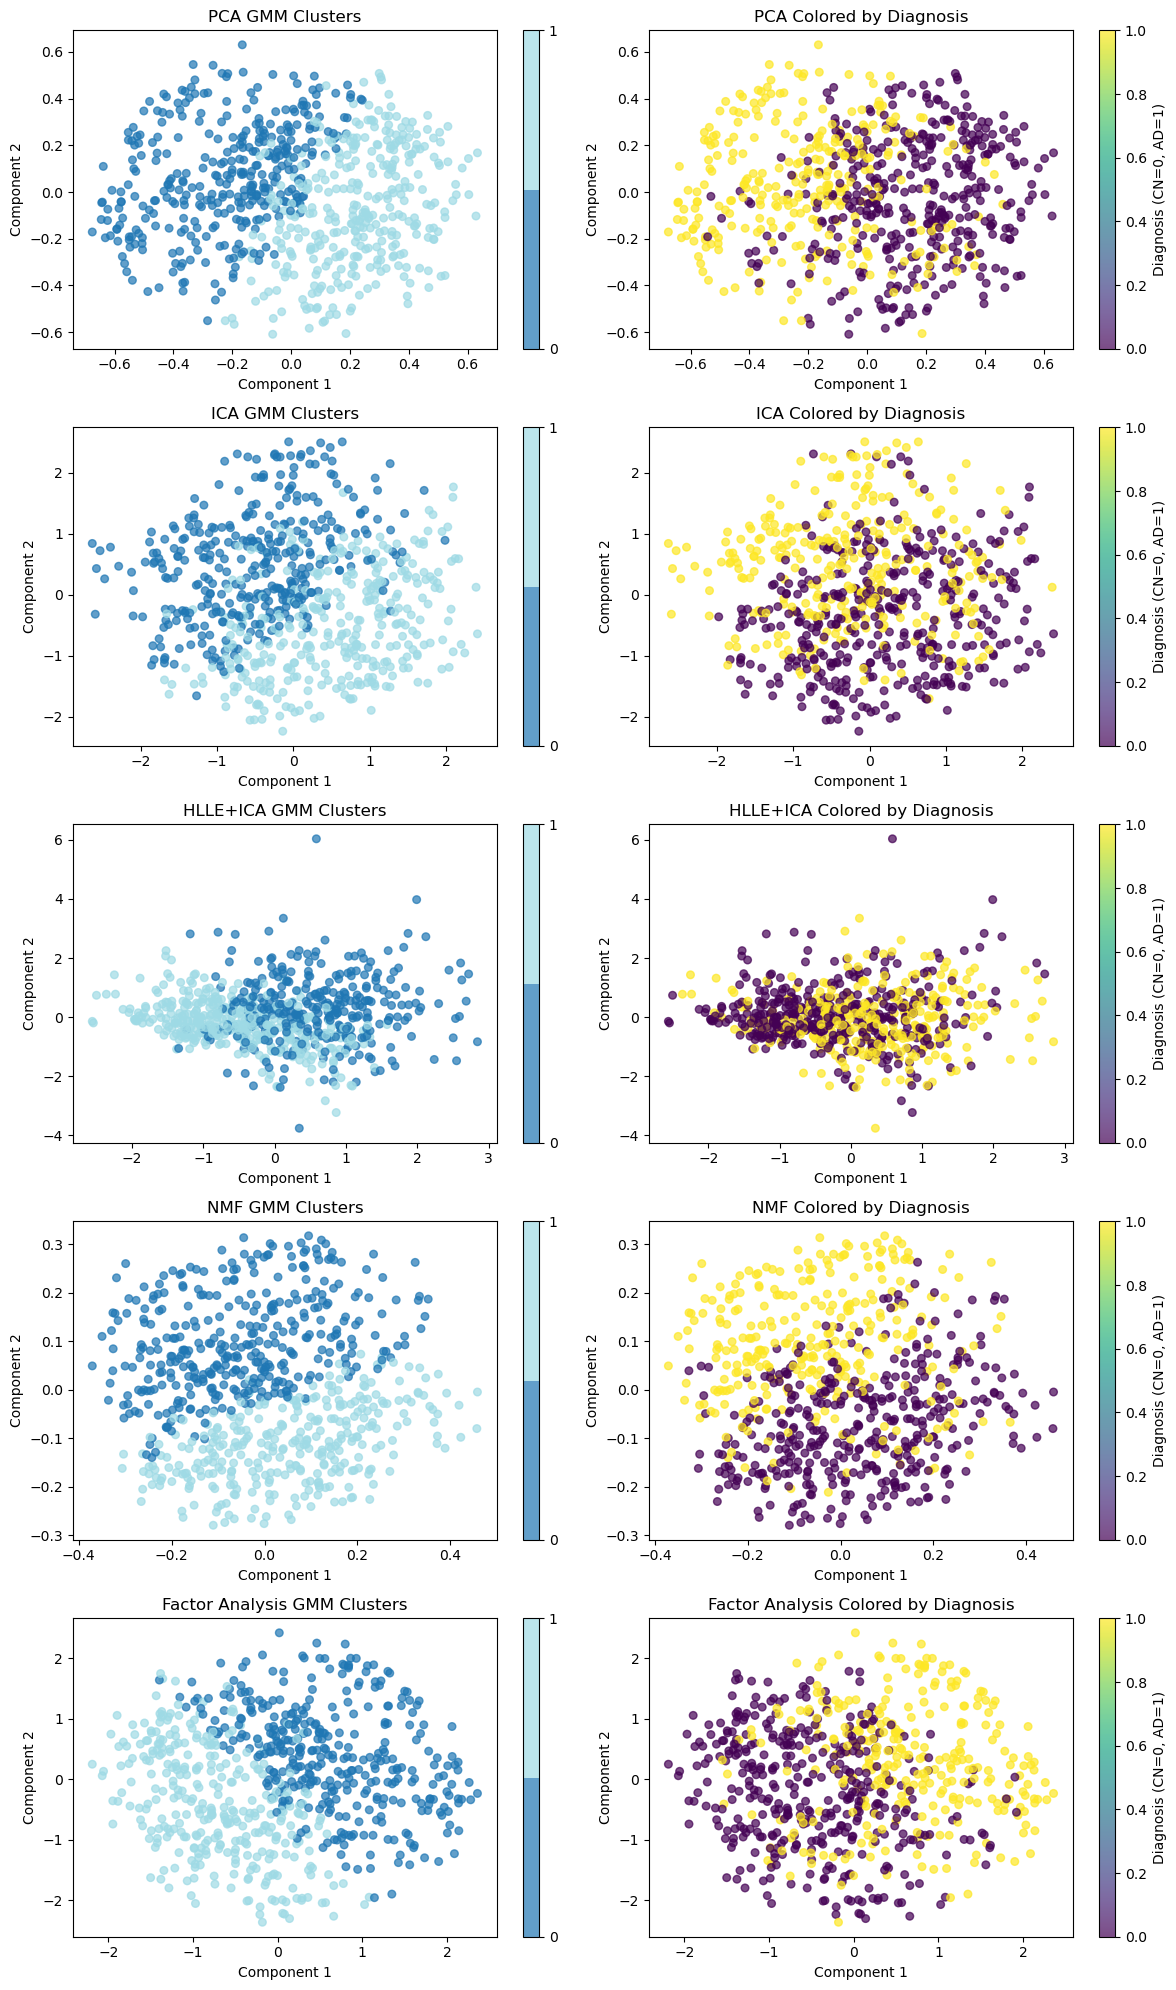

In [47]:
# 14. Visualize GMM clustering results and report purity (binary + 3-class)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter

print('\n14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'clustering_results' not in globals():
    raise RuntimeError('clustering_results not found. Run the GMM clustering cell first.')
if 'diag_bin' not in globals() or 'diag_raw_valid' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

def _cluster_purity(labels, targets, valid_values):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets)
    labels = labels[mask]
    targets = targets[mask].astype(int)
    keep = np.isin(targets, valid_values)
    labels = labels[keep]
    targets = targets[keep]
    if labels.size == 0:
        return float('nan'), {}
    details = {}
    correct = 0
    for cid in sorted(set(labels.tolist())):
        cmask = labels == cid
        t = targets[cmask]
        counts = Counter(t.tolist())
        n = sum(counts.values())
        major = max(counts.values()) if n else 0
        correct += major
        details[int(cid)] = {
            'size': int(n),
            'purity': float(major / n) if n else float('nan'),
            'breakdown': {int(k): int(v) for k, v in counts.items()},
        }
    overall = correct / len(labels)
    return float(overall), details

methods = ['PCA', 'ICA', 'HLLE+ICA', 'NMF', 'FA']
display_names = {
    'PCA': 'PCA',
    'ICA': 'ICA',
    'HLLE+ICA': 'HLLE+ICA',
    'NMF': 'NMF',
    'FA': 'Factor Analysis',
}

method_keys = []
for method in methods:
    key = f'GMM_Best_{method}'
    if key in clustering_results and results.get(method) is not None:
        method_keys.append((method, key))

if not method_keys:
    print('No GMM results found for PCA/ICA/HLLE+ICA/NMF/FA.')
else:
    n_rows = len(method_keys)
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for row_idx, (method, key) in enumerate(method_keys):
        embedding = results.get(method)
        labels = np.asarray(clustering_results[key])

        if embedding.shape[1] == 1:
            X_vis = np.column_stack([embedding[:, 0], np.zeros(len(embedding))])
        elif embedding.shape[1] == 2:
            X_vis = embedding
        else:
            X_vis = PCA(n_components=2).fit_transform(embedding)

        unique_labels = sorted(set(labels.tolist()))
        label_to_index = {lab: idx for idx, lab in enumerate(unique_labels)}
        color_ids = np.vectorize(label_to_index.get)(labels)
        cmap = plt.get_cmap('tab20', max(len(unique_labels), 1))
        method_name = display_names.get(method, method)

        ax_clusters = axes[row_idx, 0]
        sc = ax_clusters.scatter(X_vis[:, 0], X_vis[:, 1], c=color_ids, cmap=cmap, s=30, alpha=0.7)
        ax_clusters.set_title(f'{method_name} GMM Clusters')
        ax_clusters.set_xlabel('Component 1')
        ax_clusters.set_ylabel('Component 2')
        cbar = plt.colorbar(sc, ax=ax_clusters, ticks=range(len(unique_labels)))
        cbar.ax.set_yticklabels(unique_labels)

        # Binary diagnosis
        ax_bin = axes[row_idx, 1]
        mask = np.isfinite(diag_bin)
        for cls in [0, 1]:
            m = mask & (diag_bin == cls)
            if np.any(m):
                ax_bin.scatter(X_vis[m, 0], X_vis[m, 1], s=30, alpha=0.7, color=diag_bin_colors[cls], label=diag_bin_name[cls])
        ax_bin.set_title(f'{method_name} - Diagnosis (binary)')
        ax_bin.set_xlabel('Component 1')
        ax_bin.set_ylabel('Component 2')
        ax_bin.legend(loc='best')

        # 3-class diagnosis
        ax_3 = axes[row_idx, 2]
        mask = np.isfinite(diag_raw_valid)
        for cls in [-1, 0, 1]:
            m = mask & (diag_raw_valid == cls)
            if np.any(m):
                ax_3.scatter(X_vis[m, 0], X_vis[m, 1], s=30, alpha=0.7, color=diag3_colors[cls], label=diag3_name[cls])
        ax_3.set_title(f'{method_name} - Diagnosis (3-class)')
        ax_3.set_xlabel('Component 1')
        ax_3.set_ylabel('Component 2')
        ax_3.legend(loc='best')

        purity_bin, details_bin = _cluster_purity(labels, diag_bin, valid_values=[0, 1])
        purity_3, details_3 = _cluster_purity(labels, diag_raw_valid, valid_values=[-1, 0, 1])

        print(f'\n{method_name} purity (binary): {purity_bin:.3f}')
        for cid in sorted(details_bin):
            info = details_bin[cid]
            print(f"  cluster {cid}: size={info['size']}, purity={info['purity']:.3f}, breakdown={info['breakdown']}")

        print(f'{method_name} purity (3-class): {purity_3:.3f}')
        for cid in sorted(details_3):
            info = details_3[cid]
            pretty = {diag3_name.get(k, str(k)): v for k, v in info['breakdown'].items()}
            print(f"  cluster {cid}: size={info['size']}, purity={info['purity']:.3f}, breakdown={pretty}")

    plt.tight_layout()
    plt.show()


In [48]:
# 16. High-confidence GMM filtering (purity vs coverage) - binary + 3-class
import numpy as np
from sklearn.preprocessing import StandardScaler
from collections import Counter

print('\n16. High-confidence GMM filtering (purity vs coverage):')

if 'gmm_models_by_method' not in globals():
    raise RuntimeError('gmm_models_by_method not found. Run the GMM clustering cell first.')
if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'diag_bin' not in globals() or 'diag_raw_valid' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

def _cluster_purity(labels, targets, valid_values):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets)
    labels = labels[mask]
    targets = targets[mask].astype(int)
    keep = np.isin(targets, valid_values)
    labels = labels[keep]
    targets = targets[keep]
    if labels.size == 0:
        return float('nan'), {}
    correct = 0
    details = {}
    for cid in sorted(set(labels.tolist())):
        cmask = labels == cid
        t = targets[cmask]
        counts = Counter(t.tolist())
        n = sum(counts.values())
        major = max(counts.values()) if n else 0
        correct += major
        details[int(cid)] = {
            'size': int(n),
            'purity': float(major / n) if n else float('nan'),
            'breakdown': {int(k): int(v) for k, v in counts.items()},
        }
    return float(correct / len(labels)), details

threshold = 0.80  # adjust to trade purity vs coverage

for name, model in gmm_models_by_method.items():
    if model is None:
        print(f'{name}: model missing, skipping.')
        continue
    embedding = results.get(name)
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue

    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    probs = model.predict_proba(X_emb)
    conf = probs.max(axis=1)
    keep = conf >= threshold

    if keep.sum() == 0:
        print(f'{name}: no samples above threshold={threshold:.2f}.')
        continue

    labels = model.predict(X_emb)
    coverage = float(keep.mean())

    purity_bin, details_bin = _cluster_purity(labels[keep], diag_bin[keep], valid_values=[0, 1])
    purity_3, details_3 = _cluster_purity(labels[keep], diag_raw_valid[keep], valid_values=[-1, 0, 1])

    print(f'\n{name}: coverage={coverage:.3f} (threshold={threshold:.2f})')
    print(f'  purity (binary): {purity_bin:.3f}')
    for cid in sorted(details_bin):
        info = details_bin[cid]
        bd = info['breakdown']
        nonad = int(bd.get(0, 0))
        ad = int(bd.get(1, 0))
        print(f"    cluster {cid}: CN+MCI={nonad}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

    print(f'  purity (3-class): {purity_3:.3f}')
    for cid in sorted(details_3):
        info = details_3[cid]
        bd = {diag3_name.get(k, str(k)): v for k, v in info['breakdown'].items()}
        print(f"    cluster {cid}: breakdown={bd}, size={info['size']}, purity={info['purity']:.3f}")



16. High-confidence GMM filtering (purity vs coverage):

PCA: purity=0.826, coverage=0.786 (threshold=0.80)
  cluster 0: CN=59, AD=219, size=278, purity=0.788
  cluster 1: CN=233, AD=36, size=269, purity=0.866

ICA: purity=0.826, coverage=0.786 (threshold=0.80)
  cluster 0: CN=59, AD=219, size=278, purity=0.788
  cluster 1: CN=233, AD=36, size=269, purity=0.866

HLLE+ICA: purity=0.777, coverage=0.838 (threshold=0.80)
  cluster 0: CN=72, AD=198, size=270, purity=0.733
  cluster 1: CN=255, AD=58, size=313, purity=0.815

NMF: purity=0.829, coverage=0.773 (threshold=0.80)
  cluster 0: CN=68, AD=243, size=311, purity=0.781
  cluster 1: CN=203, AD=24, size=227, purity=0.894

FA: purity=0.813, coverage=0.806 (threshold=0.80)
  cluster 0: CN=69, AD=221, size=290, purity=0.762
  cluster 1: CN=235, AD=36, size=271, purity=0.867


In [49]:
# 17. GMM on full latent codes (X) + purity (binary + 3-class, with confidence filtering)
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from collections import Counter

print('\n17. GMM on full latent codes (X) + purity (with confidence filtering):')

if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')
if 'diag_bin' not in globals() or 'diag_raw_valid' not in globals():
    raise RuntimeError('Diagnosis label views not found. Run the label-view cell first.')

def _cluster_purity(labels, targets, valid_values):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets)
    labels = labels[mask]
    targets = targets[mask].astype(int)
    keep = np.isin(targets, valid_values)
    labels = labels[keep]
    targets = targets[keep]
    if labels.size == 0:
        return float('nan'), {}
    correct = 0
    details = {}
    for cid in sorted(set(labels.tolist())):
        cmask = labels == cid
        t = targets[cmask]
        counts = Counter(t.tolist())
        n = sum(counts.values())
        major = max(counts.values()) if n else 0
        correct += major
        details[int(cid)] = {
            'size': int(n),
            'purity': float(major / n) if n else float('nan'),
            'breakdown': {int(k): int(v) for k, v in counts.items()},
        }
    return float(correct / len(labels)), details

k_fixed = 2
threshold = 0.90  # adjust to trade purity vs coverage

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm_latent = GaussianMixture(n_components=k_fixed, random_state=42)
latent_labels = gmm_latent.fit_predict(X_scaled)
latent_probs = gmm_latent.predict_proba(X_scaled)

sil_score = silhouette_score(X_scaled, latent_labels) if len(set(latent_labels)) > 1 else -1.0
aic_score = gmm_latent.aic(X_scaled)
bic_score = gmm_latent.bic(X_scaled)

purity_bin_all, details_bin_all = _cluster_purity(latent_labels, diag_bin, valid_values=[0, 1])
purity_3_all, details_3_all = _cluster_purity(latent_labels, diag_raw_valid, valid_values=[-1, 0, 1])

print(f'K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')
print(f'Purity (binary): {purity_bin_all:.3f}')
for cid in sorted(details_bin_all):
    info = details_bin_all[cid]
    breakdown = info['breakdown']
    nonad = int(breakdown.get(0, 0))
    ad = int(breakdown.get(1, 0))
    print(f"  cluster {cid}: CN+MCI={nonad}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

print(f'Purity (3-class): {purity_3_all:.3f}')
for cid in sorted(details_3_all):
    info = details_3_all[cid]
    breakdown = {diag3_name.get(k, str(k)): v for k, v in info['breakdown'].items()}
    print(f"  cluster {cid}: breakdown={breakdown}, size={info['size']}, purity={info['purity']:.3f}")

conf = latent_probs.max(axis=1)
keep = conf >= threshold
if keep.sum() == 0:
    print(f'No samples above threshold={threshold:.2f}.')
else:
    purity_bin_f, details_bin_f = _cluster_purity(latent_labels[keep], diag_bin[keep], valid_values=[0, 1])
    purity_3_f, details_3_f = _cluster_purity(latent_labels[keep], diag_raw_valid[keep], valid_values=[-1, 0, 1])
    coverage = float(keep.mean())
    print(f'\nFiltered (threshold={threshold:.2f}): coverage={coverage:.3f}')

    print(f'  Purity (binary): {purity_bin_f:.3f}')
    for cid in sorted(details_bin_f):
        info = details_bin_f[cid]
        breakdown = info['breakdown']
        nonad = int(breakdown.get(0, 0))
        ad = int(breakdown.get(1, 0))
        print(f"    cluster {cid}: CN+MCI={nonad}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

    print(f'  Purity (3-class): {purity_3_f:.3f}')
    for cid in sorted(details_3_f):
        info = details_3_f[cid]
        breakdown = {diag3_name.get(k, str(k)): v for k, v in info['breakdown'].items()}
        print(f"    cluster {cid}: breakdown={breakdown}, size={info['size']}, purity={info['purity']:.3f}")

gmm_latent_results = {
    'model': gmm_latent,
    'labels': latent_labels,
    'probs': latent_probs,
    'silhouette': sil_score,
    'aic': aic_score,
    'bic': bic_score,
    'purity_bin_all': purity_bin_all,
    'purity_3_all': purity_3_all,
    'details_bin_all': details_bin_all,
    'details_3_all': details_3_all,
    'threshold': threshold,
}



17. GMM on full latent codes (X) + purity (with confidence filtering):
K=2: Silhouette=0.037, AIC=463460.4, BIC=764839.8
Purity (all): 0.823
  cluster 0: CN=65, AD=245, size=310, purity=0.790
  cluster 1: CN=328, AD=58, size=386, purity=0.850

Purity (filtered): 0.823, coverage=1.000 (threshold=0.90)
  cluster 0: CN=65, AD=245, size=310, purity=0.790
  cluster 1: CN=328, AD=58, size=386, purity=0.850
